# Thermal Conductivity Modeling of a Copper Bar

This notebook presents a reproducible numerical and data-driven analysis of 1D heat conduction in a copper bar instrumented with 11 thermocouples. The workflow compares analytical and finite-difference models against experimental measurements, then extends the analysis with parameter fitting, residual diagnostics, and an optional physics-informed neural network (PINN).

## What this notebook includes
- experimental data loading and thermocouple normalization
- finite-difference heat-conduction models with multiple boundary-condition choices
- radial heat-loss fitting and sensitivity analysis
- chi-squared and RMSE diagnostics
- optional PINN-based temperature-field reconstruction

> For a clean GitHub upload, place the raw Excel data files in the `data/` folder before running the notebook.


---
## 0. Environment Setup and Project Configuration

Run this section first. It imports the required libraries, configures plotting, and creates the standard project folders used throughout the notebook (`data/`, `figures/`, and `outputs/`).


In [ ]:
from pathlib import Path
import os
import tempfile

import matplotlib.pyplot as plt
import matplotlib.figure as _mfig
import numpy as np
import pandas as pd

# Notebook display configuration
%matplotlib inline
plt.rcParams.update({
    "figure.figsize": (10, 7),
    "font.size": 12,
    "axes.grid": False,
})

# Reproducibility for NumPy-based operations
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Project directories
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR = PROJECT_ROOT / "figures"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

for folder in (DATA_DIR, FIG_DIR, OUTPUT_DIR):
    folder.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------------------
# Figure-saving setup: prefer ./figures, but fall back to a writable
# temp folder if the working directory is read-only.
# ----------------------------------------------------------------------
try:
    _test_file = FIG_DIR / ".write_test"
    _test_file.write_text("")
    _test_file.unlink()
except (OSError, PermissionError):
    FIG_DIR = Path(tempfile.mkdtemp(prefix="thermal_figs_"))
    print(f"[figures/ not writable, falling back to {FIG_DIR}]")

_orig_plt_savefig = plt.savefig
_orig_fig_savefig = _mfig.Figure.savefig

def _redirect_output_path(path_like):
    if isinstance(path_like, str) and path_like.startswith("figures/"):
        return str(FIG_DIR / path_like[len("figures/"):])
    return path_like

def _safe_plt_savefig(fname, *args, **kwargs):
    return _orig_plt_savefig(_redirect_output_path(fname), *args, **kwargs)

def _safe_fig_savefig(self, fname, *args, **kwargs):
    return _orig_fig_savefig(self, _redirect_output_path(fname), *args, **kwargs)

plt.savefig = _safe_plt_savefig
_mfig.Figure.savefig = _safe_fig_savefig

print("Libraries loaded successfully.")
print(f"Project root : {PROJECT_ROOT}")
print(f"Data folder  : {DATA_DIR}")
print(f"Figures      : {FIG_DIR}")
print(f"Outputs      : {OUTPUT_DIR}")


In [2]:
# ============================================================
# PHYSICAL CONSTANTS — pulled from reference document and standard sources
# ============================================================

# Thermal diffusivity of copper: alpha^2 = k / (c * rho)
#   k = thermal conductivity, c = specific heat, rho = density
#   For copper: alpha^2 = 1.1027 cm^2/s
alpha_sq = 1.1027  # cm^2/s  UNITS MATTER: cm^2 per second, NOT per minute

# Room temperature (what the bar starts at before heating)
T_room = 22.0  # degrees C — adjust to YOUR room temp

# Rod geometry
thermocouple_separation = 76.25  # cm, distance between first and last thermocouple
extra_length_each_side  = 4.0    # cm, estimated extra rod beyond thermocouples
L = thermocouple_separation + 2 * extra_length_each_side  # total model rod length
print(f"Total model rod length: L = {L} cm")

# Time and space steps for the finite difference method
dx = 0.25    # cm — spatial step size
dt = 0.004   # seconds — time step size

# Total simulation time
# Your heating phase data has ~3500 useful rows (7000 seconds).
# We'll model 1200 seconds (20 min) to start — same as the reference document.
# You can increase this later if you want to capture longer behavior.
total_time = 1200  # seconds (= 20 minutes)

# Calculate the stability parameter D
# D MUST be < 0.5 or the simulation will blow up with oscillations!
D = alpha_sq * dt / (dx**2)
print(f"Stability parameter D = {D:.6f}")
if D >= 0.5:
    print("WARNING: D >= 0.5! Your simulation will be unstable!")
    print("   Try making dt smaller or dx larger.")
else:
    print("D < 0.5 — simulation should be stable.")

Total model rod length: L = 84.25 cm
Stability parameter D = 0.070573
D < 0.5 — simulation should be stable.


In [3]:
# ============================================================
# GRID SETUP — how many rows/columns in our temperature array
# ============================================================

# Number of spatial points (columns in our array)
num_cols = round(L / dx) + 1
print(f"Number of spatial points (columns): {num_cols}")

# Number of time steps (rows in our array)
num_rows = round(total_time / dt) + 1
print(f"Number of time steps (rows): {num_rows}")
print(f"  (That's a {num_rows} x {num_cols} array — {num_rows*num_cols:,} total values!)")

# Create the x-position array (in cm)
x_array = np.linspace(0, L, num_cols)

# Times we want to plot (in seconds)
plot_times = [0, 60, 120, 240, 360, 480, 600, 720, 1200]

# Convert those times to row indices in our array
plot_indices = [round(t / dt) for t in plot_times]

# Colors for each time curve (to match the reference document)
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive']

Number of spatial points (columns): 338
Number of time steps (rows): 300001
  (That's a 300001 x 338 array — 101,400,338 total values!)


---
## 1. Load Experimental Data

These cells let you switch between **Run 1** (heating), **Run 2** (cooling), or **Run 3/4** (cooling) without rewriting the workflow. Set `active_run` in the selector cell, then place the corresponding Excel files in the repository `data/` folder.

Expected filenames:
- `run_1.xlsx`
- `run_2.xlsx`
- `run_3.xlsx`
- `Run_4.xlsx`


In [ ]:
from pathlib import Path
import pandas as pd

# ----------------------------------------------------------------------
# Run-file resolver: accepts canonical filenames plus common duplicate
# upload variants such as "(1)" suffixes.
# ----------------------------------------------------------------------
def _resolve_run_path(base_name: str) -> Path:
    stem = Path(base_name).stem
    suffix = Path(base_name).suffix
    candidates = [
        base_name,
        f"{stem}(1){suffix}",
        f"{stem} (1){suffix}",
        f"{stem}_(1){suffix}",
        base_name.replace("Run_", "run_"),
        base_name.replace("run_", "Run_"),
        f"{stem}(1){suffix}".replace("Run_", "run_"),
        f"{stem}(1){suffix}".replace("run_", "Run_"),
    ]

    for name in candidates:
        candidate = DATA_DIR / name
        if candidate.exists():
            return candidate

    expected = ", ".join(sorted({str(DATA_DIR / name) for name in candidates[:4]}))
    raise FileNotFoundError(
        "Could not locate the requested Excel dataset. "
        f"Add the file to the data/ folder. Tried: {expected}"
    )

run_files = {
    "run1": "run_1.xlsx",
    "run2": "run_2.xlsx",
    "run3": "run_3.xlsx",
    "run4": "Run_4.xlsx",
}

# Select the dataset to analyze
active_run = "run2"

# Phase configuration
# Run 1 : heating phase (heater ON, starts at row 3622)
# Run 2 : cooling phase (heater OFF, starts at row 4270)
# Run 3 : cooling phase (heater OFF, starts at row 3282)
# Run 4 : cooling phase (heater OFF, starts at row 3962, peak ~70 C)
start_rows = {
    "run1": 3622,
    "run2": 4270,
    "run3": 3282,
    "run4": 3962,
}

run_phase = {
    "run1": "heating",
    "run2": "cooling",
    "run3": "cooling",
    "run4": "cooling",
}

phase = run_phase[active_run]
data_file = _resolve_run_path(run_files[active_run])
start_row = start_rows[active_run]

# Load full data from Excel (no header row; data begins on row 1)
raw_data_full = pd.read_excel(data_file, header=None, engine="openpyxl").values

# Slice to the working phase
raw_data = raw_data_full[start_row:, :]

print(f"Active dataset : {active_run} ({phase} phase)")
print(f"Source file    : {data_file.name}")
print(f"Start row      : {start_row}")
print(f"Full shape     : {raw_data_full.shape}")
print(f"Working shape  : {raw_data.shape}")
print(f"{raw_data.shape[0]} time points x {raw_data.shape[1]} thermocouples")

total_time_data = (raw_data.shape[0] - 1) * 2
print(f"Available time : {total_time_data} s ({total_time_data / 60:.1f} min)")

print("\nFirst working row (t = 0 s in notebook):")
print(np.array2string(raw_data[0, :], precision=1))

if raw_data.shape[0] > 600:
    print("\nRow 601 (t = 1200 s):")
    print(np.array2string(raw_data[600, :], precision=1))
else:
    print(f"\nDataset has only {raw_data.shape[0]} rows (< 601).")


### Quick comparison of Run 1 and Run 2

This optional check overlays the hot-end and cold-end thermocouples for both runs, so you can quickly see whether the two experiments have similar heating behavior before committing to one for modeling.


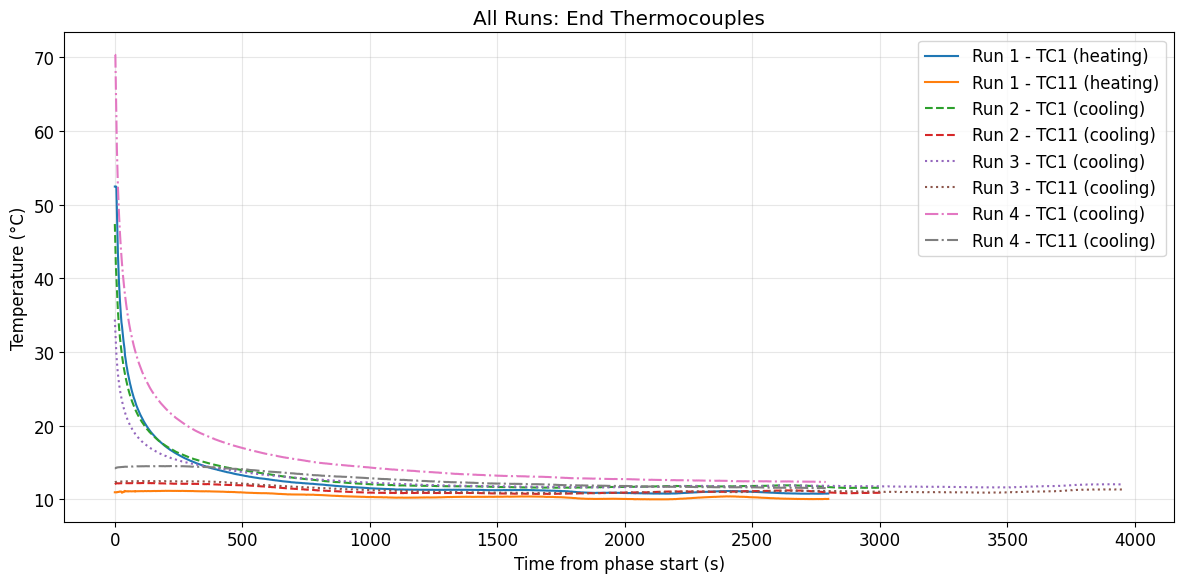

In [5]:
# ============================================================
# OPTIONAL: COMPARE ALL RUNS AT THE ENDS OF THE BAR
# ============================================================
r1_full = pd.read_excel(run_files['run1'], header=None).values
r2_full = pd.read_excel(run_files['run2'], header=None).values
r3_full = pd.read_excel(run_files['run3'], header=None).values
r4_full = pd.read_excel(run_files['run4'], header=None).values

# Slice each to its working phase
r1 = r1_full[start_rows['run1']:, :]
r2 = r2_full[start_rows['run2']:, :]
r3 = r3_full[start_rows['run3']:, :]
r4 = r4_full[start_rows['run4']:, :]

t1 = np.arange(r1.shape[0]) * 2
t2 = np.arange(r2.shape[0]) * 2
t3 = np.arange(r3.shape[0]) * 2
t4 = np.arange(r4.shape[0]) * 2

plt.figure(figsize=(12, 6))
plt.plot(t1, r1[:, 0],  label='Run 1 - TC1 (heating)')
plt.plot(t1, r1[:, 10], label='Run 1 - TC11 (heating)')
plt.plot(t2, r2[:, 0],  '--', label='Run 2 - TC1 (cooling)')
plt.plot(t2, r2[:, 10], '--', label='Run 2 - TC11 (cooling)')
plt.plot(t3, r3[:, 0],  ':', label='Run 3 - TC1 (cooling)')
plt.plot(t3, r3[:, 10], ':', label='Run 3 - TC11 (cooling)')
plt.plot(t4, r4[:, 0],  '-.', label='Run 4 - TC1 (cooling)')
plt.plot(t4, r4[:, 10], '-.', label='Run 4 - TC11 (cooling)')
plt.xlabel('Time from phase start (s)')
plt.ylabel('Temperature (°C)')
plt.title('All Runs: End Thermocouples')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### Thermocouple Normalization (Room Temperature Offset Correction)

Before the heater and water were turned on, all thermocouples should have read the same room temperature.
However, each thermocouple has a small systematic offset — some read a bit high, some a bit low.

We use the **very first row** of data (before anything was turned on) to measure each thermocouple's offset
from the group average. Then we subtract that offset from **all** subsequent readings.

This "normalization" removes systematic instrument bias and makes the data more accurate.

In [6]:
# ============================================================
# THERMOCOUPLE NORMALIZATION — Room Temperature Offset Correction
# ============================================================
# Use the first row of the FULL selected run as the room-temperature baseline.
# Then subtract each thermocouple's offset from the average baseline temperature.

baseline = raw_data_full[0, :]
baseline_mean = np.mean(baseline)
offsets = baseline - baseline_mean

print("Baseline row from full selected run:")
print(np.array2string(baseline, precision=2))
print(f"Baseline average room temperature = {baseline_mean:.3f} °C")
print("\nThermocouple offsets (TC reading - baseline average):")
print(np.array2string(offsets, precision=3))

# Apply correction to the working dataset used by the rest of the notebook
raw_data = raw_data - offsets[np.newaxis, :]

print("\nFirst corrected working row:")
print(np.array2string(raw_data[0, :], precision=2))


Baseline row from full selected run:
[21.81 21.74 21.66 21.6  21.55 21.52 21.45 21.4  21.33 21.24 21.15]
Baseline average room temperature = 21.495 °C

Thermocouple offsets (TC reading - baseline average):
[ 0.316  0.242  0.163  0.108  0.058  0.024 -0.048 -0.099 -0.165 -0.251
 -0.348]

First corrected working row:
[47.05 43.22 39.38 35.93 32.66 29.2  25.73 22.5  19.16 15.86 12.4 ]


In [7]:
# ============================================================
# THERMOCOUPLE POSITIONS
# ============================================================
# The 11 thermocouples are evenly spaced along the 76.25 cm bar.
# We shift them by extra_length_each_side so that x=0 is the
# left end of the MODEL rod (not the first thermocouple).
#
# Original positions: 0, 7.625, 15.25, ... , 76.25 cm
# After shifting by 4 cm:

tc_positions = np.array([4.0, 11.625, 19.25, 26.875, 34.5, 42.125,
                         49.75, 57.375, 65.0, 72.625, 80.25])

print(f"Thermocouple positions (cm): {tc_positions}")
print(f"Number of thermocouples: {len(tc_positions)}")

Thermocouple positions (cm): [ 4.    11.625 19.25  26.875 34.5   42.125 49.75  57.375 65.    72.625
 80.25 ]
Number of thermocouples: 11


In [8]:
# ============================================================
# EXTRACT TEMPERATURE SNAPSHOTS AT SPECIFIC TIMES
# ============================================================
# Your data is sampled every 2 seconds, so:
#   row index = time_in_seconds / 2
#
# In your data:
#   Column 0 = TC1 (hot end, LEFT side)
#   Column 10 = TC11 (cold end, RIGHT side)
#
# The reference document has the cold end on the LEFT and hot on the RIGHT.
# YOUR data has hot on the LEFT and cold on the RIGHT.
# We do NOT need to flip anything — the physics is the same either way.
# We just need to keep our labeling consistent.

data_t0    = raw_data[0, :]        # t = 0 s    (row 0)
data_t60   = raw_data[30, :]       # t = 60 s   (row 30)
data_t120  = raw_data[60, :]       # t = 120 s  (row 60)
data_t240  = raw_data[120, :]      # t = 240 s  (row 120)
data_t360  = raw_data[180, :]      # t = 360 s  (row 180)
data_t480  = raw_data[240, :]      # t = 480 s  (row 240)
data_t600  = raw_data[300, :]      # t = 600 s  (row 300)
data_t720  = raw_data[360, :]      # t = 720 s  (row 360)
data_t1200 = raw_data[600, :]      # t = 1200 s (row 600)

# Bundle them into a list for easy looping later
all_data = [data_t0, data_t60, data_t120, data_t240, data_t360,
            data_t480, data_t600, data_t720, data_t1200]

# Quick sanity check — print the data
for label, d in zip(plot_times, all_data):
    print(f"t = {label:>5d} s:  TC1(hot)={d[0]:.1f}  TC6(mid)={d[5]:.1f}  TC11(cold)={d[10]:.1f}")

t =     0 s:  TC1(hot)=47.0  TC6(mid)=29.2  TC11(cold)=12.4
t =    60 s:  TC1(hot)=23.8  TC6(mid)=29.2  TC11(cold)=12.5
t =   120 s:  TC1(hot)=19.5  TC6(mid)=28.9  TC11(cold)=12.6
t =   240 s:  TC1(hot)=16.1  TC6(mid)=27.1  TC11(cold)=12.5
t =   360 s:  TC1(hot)=14.7  TC6(mid)=24.8  TC11(cold)=12.4
t =   480 s:  TC1(hot)=13.8  TC6(mid)=22.7  TC11(cold)=12.3
t =   600 s:  TC1(hot)=13.1  TC6(mid)=20.9  TC11(cold)=12.0
t =   720 s:  TC1(hot)=12.5  TC6(mid)=19.4  TC11(cold)=11.7
t =  1200 s:  TC1(hot)=11.5  TC6(mid)=15.4  TC11(cold)=11.2


In [9]:
# Data validation checks
assert raw_data.shape[0] >= 601, f"Dataset too short ({raw_data.shape[0]} rows < 601 needed for 1200s)"
assert raw_data.shape[1] == 11, f"Expected 11 thermocouples, got {raw_data.shape[1]}"
print("Data validation passed.")

Data validation passed.


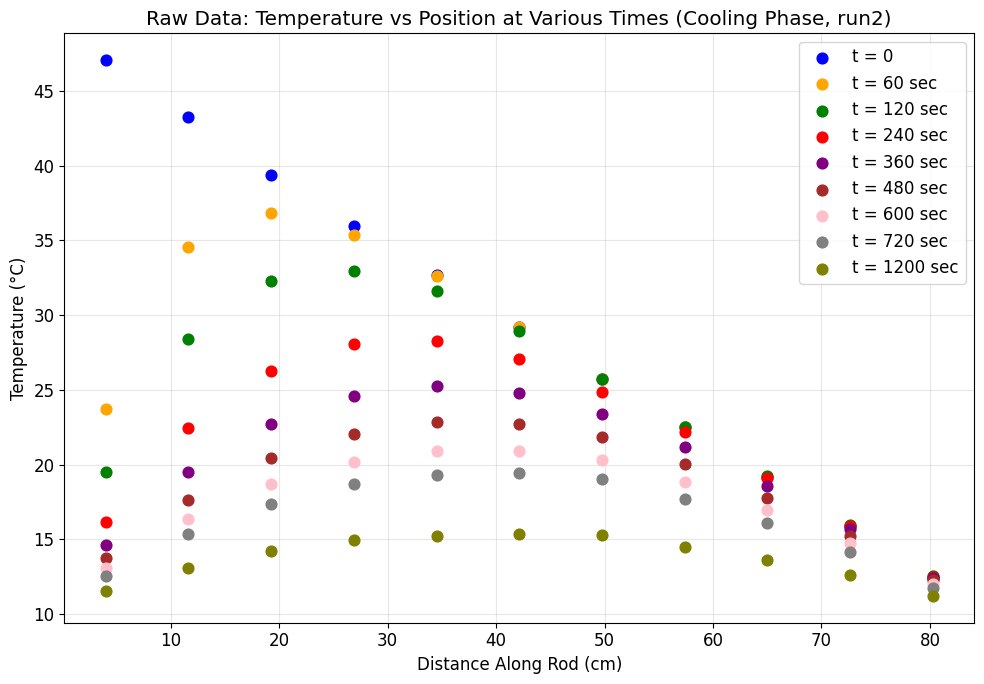

Notice: at t=0, the bar is roughly at room temperature (~22 C).
Over time, the left side (TC1) heats up and the right side (TC11) cools down.


In [10]:
# ============================================================
# QUICK LOOK: Plot the raw data snapshots
# ============================================================
# This helps you see what's going on before we start modeling.

plt.figure(figsize=(10, 7))
for k, (t_val, data_snap) in enumerate(zip(plot_times, all_data)):
    label = f't = {t_val} sec' if t_val > 0 else 't = 0'
    plt.scatter(tc_positions, data_snap, color=colors[k], s=60, label=label, zorder=5)

plt.xlabel('Distance Along Rod (cm)')
plt.ylabel('Temperature (°C)')
plt.title(f'Raw Data: Temperature vs Position at Various Times ({phase.title()} Phase, {active_run})')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/raw_data_snapshots.png', dpi=150)
plt.show()
print("Notice: at t=0, the bar is roughly at room temperature (~22 C).")
print("Over time, the left side (TC1) heats up and the right side (TC11) cools down.")

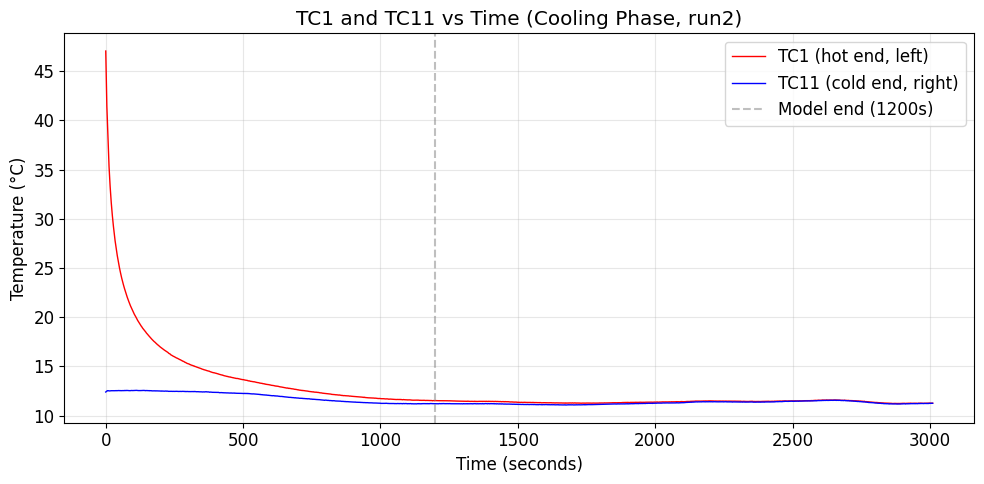

In [11]:
# ============================================================
# PLOT: Hot end and cold end temperatures vs time
# ============================================================
# This is like Fig 2 in the reference document.

time_axis = np.arange(raw_data.shape[0]) * 2  # convert row index to seconds

plt.figure(figsize=(10, 5))
plt.plot(time_axis, raw_data[:, 0], 'r-', linewidth=1, label='TC1 (hot end, left)')
plt.plot(time_axis, raw_data[:, 10], 'b-', linewidth=1, label='TC11 (cold end, right)')
plt.axvline(x=total_time, color='gray', linestyle='--', alpha=0.5, label=f'Model end ({total_time}s)')
plt.xlabel('Time (seconds)')
plt.ylabel('Temperature (°C)')
plt.title(f'TC1 and TC11 vs Time ({phase.title()} Phase, {active_run})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/hot_cold_vs_time.png', dpi=150)
plt.show()

In [12]:
# ============================================================
# INITIAL CONDITION — temperature distribution at t=0
# ============================================================
# Heating: bar starts ~room temperature with slight gradient.
# Cooling: bar starts with a hot-to-cold gradient from the heating phase.

slope, intercept = np.polyfit(tc_positions, data_t0, 1)
print(f"Initial linear fit: T = {slope:.4f} * x + {intercept:.2f}")
print(f"  At x=0:  T = {intercept:.2f} °C")
print(f"  At x={L}: T = {slope*L + intercept:.2f} °C")

if phase == 'heating':
    # Cold water temperature from TC11 after it stabilises
    T_cold = np.mean(raw_data[300:601, 10])
    print(f"\nEstimated cold water temperature: T_cold = {T_cold:.2f} °C")
else:
    # For cooling, T_cold is where the bar is heading (late-time cold end).
    T_cold = np.mean(raw_data[-100:, 10])
    print(f"\nEstimated cold-end equilibrium: T_cold = {T_cold:.2f} °C")
    print(f"TC1 at t=0 of cooling: {data_t0[0]:.2f} °C")
    print(f"TC11 at t=0 of cooling: {data_t0[-1]:.2f} °C")


Initial linear fit: T = -0.4496 * x + 48.31
  At x=0:  T = 48.31 °C
  At x=84.25: T = 10.43 °C

Estimated cold-end equilibrium: T_cold = 11.22 °C
TC1 at t=0 of cooling: 47.05 °C
TC11 at t=0 of cooling: 12.40 °C


---
## 2. Helper Function — The Plotting Routine

This function makes the comparison plots so we don't repeat code for every model.

In [13]:
def plot_model_vs_data(u, title, save_name=None):
    """
    Plot model curves (lines) and experimental data (dots) on the same graph.

    Parameters:
        u         : the 2D temperature array from the simulation
        title     : string for the plot title
        save_name : if given, saves the figure to figures/ folder
    """
    plt.figure(figsize=(10, 7))

    for k, (t_idx, t_val) in enumerate(zip(plot_indices, plot_times)):
        # Make sure we don't go out of bounds
        if t_idx >= u.shape[0]:
            t_idx = u.shape[0] - 1

        label = f't = {t_val} sec' if t_val > 0 else 't = 0'

        # Plot model as a solid line
        plt.plot(x_array, u[t_idx, :], color=colors[k], label=label)

        # Plot actual data as big dots
        plt.scatter(tc_positions, all_data[k], color=colors[k], s=60, zorder=5)

    plt.xlabel('Distance Along Rod (cm)')
    plt.ylabel('Temperature (°C)')
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_name:
        plt.savefig(f'figures/{save_name}.png', dpi=150)
        print(f"  Figure saved to figures/{save_name}.png")

    plt.show()

print("Plotting function defined!")

Plotting function defined!


---
## 3. Model 0 — Analytic (Fourier Series) Solution

Before we do the numerical simulation, let's compute the **exact analytical solution** for the simplest case. This uses a Fourier series:

$$U(x,t) = \frac{2KL}{\pi} \sum_{n=1}^{\infty} \left[ -\frac{(-1)^n}{n} \exp\left(-\alpha^2 \left(\frac{n\pi}{L}\right)^2 t\right) \sin\frac{n\pi x}{L} \right]$$

where $U = T - T_{cold}$ and $K$ is the slope of the initial linear temperature distribution.

**Note:** This analytic solution assumes BOTH ends are held at T_cold for all t > 0, which is very unrealistic for the heating phase (the hot end is NOT at T_cold!). Don't expect a great fit — this is just a check that the math and numerics agree.

Analytic model rebuilt from measured initial profile.
Using 200 Fourier terms
T_cold = 11.216 °C
Initial profile max above T_cold = 35.831 °C


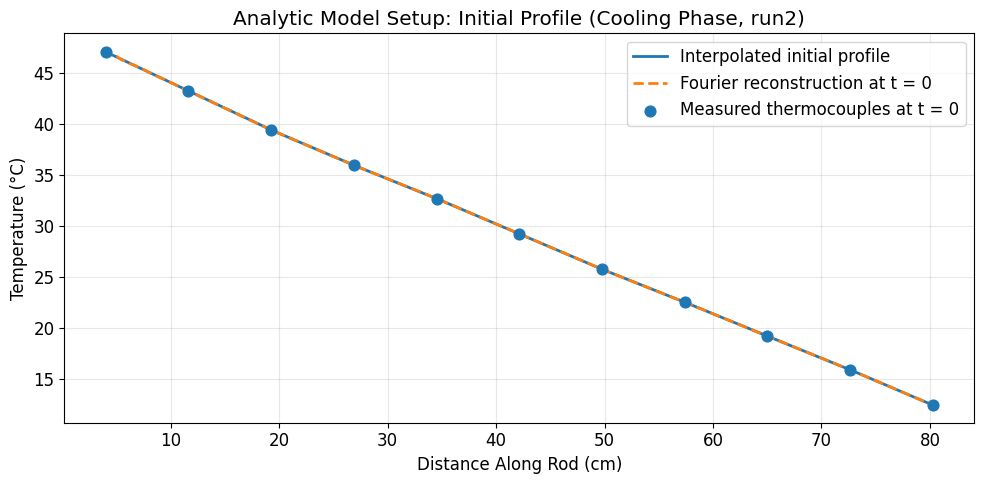

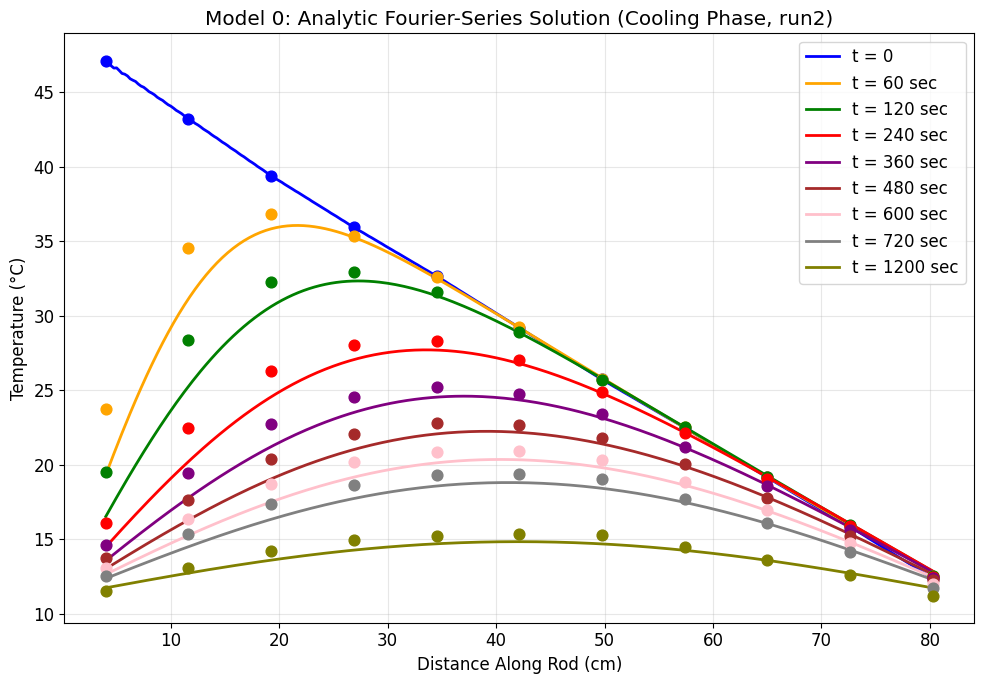

Model 0 complete!
The Fourier solution still uses T(0)=T_cold and T(L)=T_cold internally,
but those artificial endpoint ramps are now hidden from the graph.


In [14]:

# ============================================================
# MODEL 0: ANALYTIC (GENERAL FOURIER-SERIES) SOLUTION
# ============================================================
# Build the analytic model from the measured t = 0 profile, but
# do NOT draw the artificial endpoint connection on the graph.
# The T_cold endpoints are only there so the Fourier series can
# satisfy the Dirichlet boundary condition mathematically.

def build_analytic_initial_profile(x_grid, tc_positions, data_t0, L, T_cold):
    """
    Build U(x,0) = T(x,0) - T_cold on the full model grid using the
    measured thermocouple profile at t = 0 and idealized endpoints:
        T(0) = T_cold,  T(L) = T_cold

    Returns both:
      1) the computational profile used in the Fourier series
      2) a display profile that hides the artificial endpoint ramps
    """
    x_known = np.concatenate(([0.0], tc_positions, [L]))
    T_known = np.concatenate(([T_cold], data_t0, [T_cold]))

    order = np.argsort(x_known)
    x_known = x_known[order]
    T_known = T_known[order]

    # Full profile used for coefficient calculation
    T_init_full = np.interp(x_grid, x_known, T_known)
    U_init_full = T_init_full - T_cold

    # Display-only profile: hide the artificial ramps from x=0 to first TC
    # and from last TC to x=L so the graph reflects only measured/interpolated region
    T_init_display = T_init_full.copy()
    interior_mask = (x_grid >= tc_positions.min()) & (x_grid <= tc_positions.max())
    T_init_display[~interior_mask] = np.nan

    return T_init_full, U_init_full, T_init_display, x_known, T_known, interior_mask


def compute_fourier_coeffs(x_grid, U_init, L, n_terms=200):
    """
    Compute sine-series coefficients for a general initial condition:
        U(x,0) = sum b_n sin(n pi x / L)
    using numerical integration on the model grid.
    """
    coeffs = np.zeros(n_terms)

    for n in range(1, n_terms + 1):
        sine = np.sin(n * np.pi * x_grid / L)
        integrand = U_init * sine
        coeffs[n - 1] = (2.0 / L) * np.trapezoid(integrand, x_grid)

    return coeffs


def analytic_solution_general(x, t, coeffs, L, alpha_sq):
    """
    Evaluate the general Fourier-series solution for the 1D heat equation
    with both ends held at T_cold after shifting to U = T - T_cold.
    """
    U = np.zeros_like(x, dtype=float)

    for n, bn in enumerate(coeffs, start=1):
        U += bn * np.exp(-alpha_sq * (n * np.pi / L)**2 * t) * np.sin(n * np.pi * x / L)

    return U


os.makedirs('figures', exist_ok=True)

# Build the corrected initial profile and coefficients
T_init_analytic, U_init_analytic, T_init_display, x_known_analytic, T_known_analytic, analytic_plot_mask = build_analytic_initial_profile(
    x_array, tc_positions, data_t0, L, T_cold
)

n_terms_analytic = 200
fourier_coeffs = compute_fourier_coeffs(x_array, U_init_analytic, L, n_terms=n_terms_analytic)

print("Analytic model rebuilt from measured initial profile.")
print(f"Using {n_terms_analytic} Fourier terms")
print(f"T_cold = {T_cold:.3f} °C")
print(f"Initial profile max above T_cold = {U_init_analytic.max():.3f} °C")

# Optional check: reconstructed t = 0 profile from the Fourier series
U_recon_0 = analytic_solution_general(x_array, 0.0, fourier_coeffs, L, alpha_sq)
T_recon_0 = U_recon_0 + T_cold

plt.figure(figsize=(10, 5))
plt.plot(x_array, T_init_display, linewidth=2, label='Interpolated initial profile')
plt.plot(x_array[analytic_plot_mask], T_recon_0[analytic_plot_mask], '--', linewidth=2, label='Fourier reconstruction at t = 0')
plt.scatter(tc_positions, data_t0, s=60, zorder=5, label='Measured thermocouples at t = 0')
plt.xlabel('Distance Along Rod (cm)')
plt.ylabel('Temperature (°C)')
plt.title(f'Analytic Model Setup: Initial Profile ({phase.title()} Phase, {active_run})')
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('figures/model0_initial_profile_check.png', dpi=150)
plt.show()

# Main analytic-model plot
plt.figure(figsize=(10, 7))

for k, t_val in enumerate(plot_times):
    U = analytic_solution_general(x_array, t_val, fourier_coeffs, L, alpha_sq)
    T = U + T_cold

    label = f't = {t_val} sec' if t_val > 0 else 't = 0'

    # Plot only across the thermocouple span so the artificial endpoint
    # connection to T_cold does not show up on the figure.
    plt.plot(x_array[analytic_plot_mask], T[analytic_plot_mask], color=colors[k], label=label, linewidth=2)
    plt.scatter(tc_positions, all_data[k], color=colors[k], s=60, zorder=5)

plt.xlabel('Distance Along Rod (cm)')
plt.ylabel('Temperature (°C)')
plt.title(f'Model 0: Analytic Fourier-Series Solution ({phase.title()} Phase, {active_run})')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/model0_analytic_fixed.png', dpi=150)
plt.show()

print("Model 0 complete!")
print("The Fourier solution still uses T(0)=T_cold and T(L)=T_cold internally,")
print("but those artificial endpoint ramps are now hidden from the graph.")


### Improving the Fit: Transitioning to Numerical Finite Difference

While the analytic solution is a great mathematical check, it fails to capture the complexity of the experiment. We will now implement **Model 2** (using your experimental data as boundary conditions) and **Model 3** (adding radial heat loss).

---
## 4. Model 1 — Simplest Boundary Conditions

Now we do the **numerical** finite difference simulation.

**Boundary conditions:**
- Left end (x=0): T = T_cold for all time
- Right end (x=L): T = T_cold for all time

This is the simplest but least realistic model. The key equation is:

$$u_{i+1,j} = u_{i,j} + D \cdot [u_{i,j+1} - 2 u_{i,j} + u_{i,j-1}]$$

**For the heating phase, this model will be especially bad** because the hot end is NOT at T_cold — it's getting hotter over time. But it's a good sanity check that your code works before adding realistic boundaries.

Running Model 1 simulation (101,400,338 values)...
Done!
  Figure saved to figures/model1_simple.png


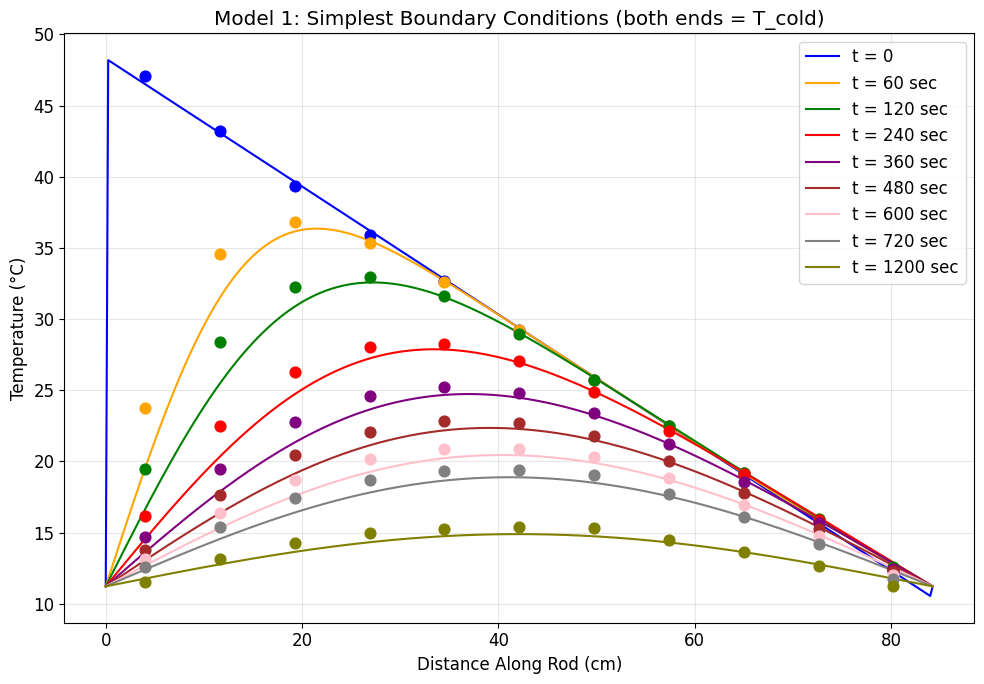

In [15]:
# ============================================================
# MODEL 1: Both ends held at T_cold
# ============================================================

# Step 1: Create a big 2D array filled with zeros
#   Rows = time steps, Columns = spatial positions
u_model1 = np.zeros((num_rows, num_cols))

# Step 2: Set the initial condition (row 0) — linear temperature profile
u_model1[0, :] = slope * x_array + intercept

# Step 3: Set boundary conditions
#   Left end (column 0) = T_cold for all time
u_model1[:, 0] = T_cold
#   Right end (last column) = T_cold for all time
u_model1[:, -1] = T_cold

# Step 4: Run the simulation (vectorized — ~50x faster than a double for-loop)
print(f"Running Model 1 simulation ({num_rows * num_cols:,} values)...")

for i in range(num_rows - 1):
    u_model1[i+1, 1:-1] = (
        u_model1[i, 1:-1]
        + D * (u_model1[i, 2:] - 2 * u_model1[i, 1:-1] + u_model1[i, :-2])
    )

print("Done!")

# Step 5: Plot the results
plot_model_vs_data(u_model1, 'Model 1: Simplest Boundary Conditions (both ends = T_cold)', 'model1_simple')


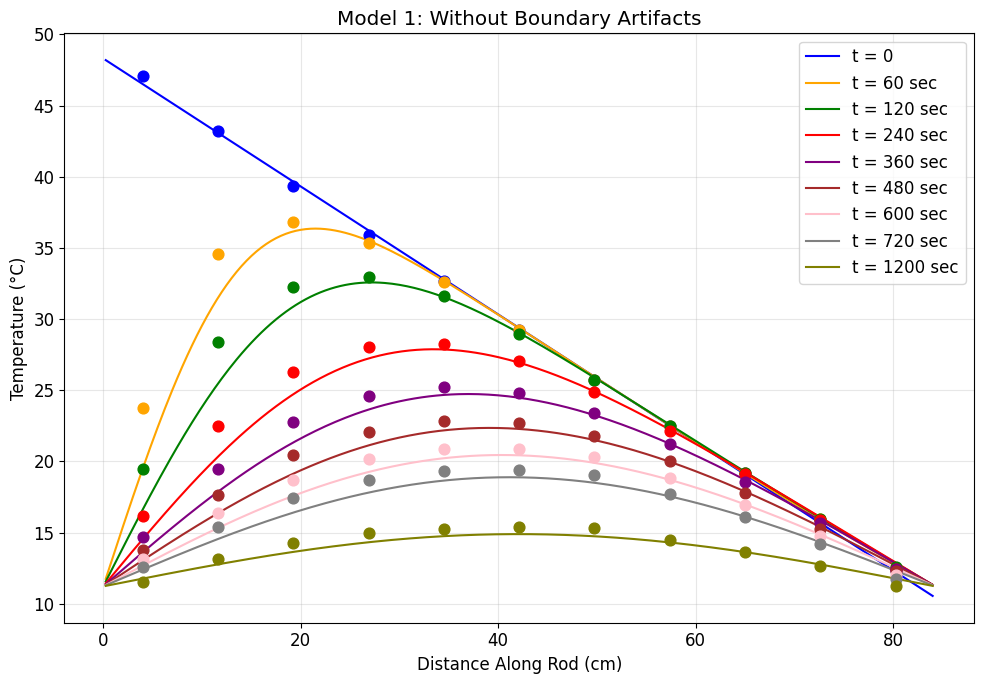

In [16]:
# Option 1: Exclude the boundary points from the plot
plt.figure(figsize=(10, 7))

for k, (t_idx, t_val) in enumerate(zip(plot_indices, plot_times)):
    if t_idx >= u_model1.shape[0]:
        t_idx = u_model1.shape[0] - 1

    label = f't = {t_val} sec' if t_val > 0 else 't = 0'

    # Plot only interior points (skip j=0 and j=-1)
    plt.plot(x_array[1:-1], u_model1[t_idx, 1:-1], color=colors[k], label=label)
    plt.scatter(tc_positions, all_data[k], color=colors[k], s=60, zorder=5)

plt.xlabel('Distance Along Rod (cm)')
plt.ylabel('Temperature (°C)')
plt.title('Model 1: Without Boundary Artifacts')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**What to look for:** This model forces both ends to T_cold immediately, so the simulation will just show the initial slight gradient decaying to T_cold everywhere. It won't capture the heating at all! That's expected — we need realistic boundaries.

---
## 5. Model 2 — Realistic Boundary Conditions from Your Data

Instead of forcing both ends to T_cold, we use the **actual temperature data** from your hottest thermocouple (TC1) as the left-hand boundary condition, and your coldest thermocouple (TC11) as the right-hand boundary.

This requires interpolating between your data points since the data is taken every 2 seconds but our time step is much smaller (0.004 s).

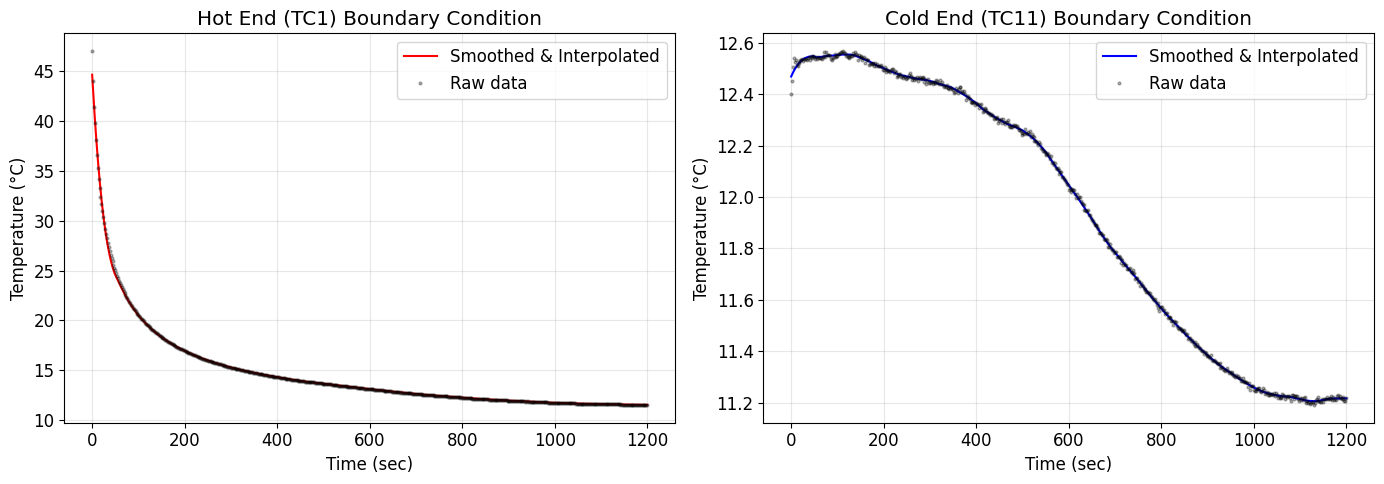

Hot end:  starts at 44.7 C, ends at 11.5 C
Cold end: starts at 12.5 C, ends at 11.2 C


In [17]:
# ============================================================
# LOAD BOUNDARY DATA FROM YOUR THERMOCOUPLES (IMPROVED)
# ============================================================
# We read the hot-end (TC1) and cold-end (TC11) data directly
# from your data file, apply a smoothing filter to remove sensor noise,
# then interpolate to match our fine time grid.

from scipy.signal import savgol_filter

# Time values for each row of your data file (every 2 seconds)
data_times = np.arange(raw_data.shape[0]) * 2.0  # in seconds

# Extract the boundary thermocouple columns
hot_raw  = raw_data[:, 0]   # TC1 = hot end (LEFT side)
cold_raw = raw_data[:, 10]  # TC11 = cold end (RIGHT side)

# Smooth the raw data using a Savitzky-Golay filter
# This removes high-frequency noise which can destabilize the simulation
window = min(51, len(raw_data) // 2 * 2 + 1)  # Window must be odd
hot_end_data  = savgol_filter(hot_raw, window_length=window, polyorder=3)
cold_end_data = savgol_filter(cold_raw, window_length=window, polyorder=3)

# Create the fine time grid for the simulation
all_times = np.arange(0, total_time + dt, dt)[:num_rows]

# Interpolate the smoothed boundary data onto the fine time grid
hot_end_interp  = np.interp(all_times, data_times, hot_end_data)
cold_end_interp = np.interp(all_times, data_times, cold_end_data)

# Quick plot to check the interpolation looks right
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(all_times, hot_end_interp, 'r-', linewidth=1.5, label='Smoothed & Interpolated')
ax1.plot(data_times[:601], hot_raw[:601], 'ko', markersize=2, alpha=0.3, label='Raw data')
ax1.set_xlabel('Time (sec)')
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Hot End (TC1) Boundary Condition')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(all_times, cold_end_interp, 'b-', linewidth=1.5, label='Smoothed & Interpolated')
ax2.plot(data_times[:601], cold_raw[:601], 'ko', markersize=2, alpha=0.3, label='Raw data')
ax2.set_xlabel('Time (sec)')
ax2.set_ylabel('Temperature (°C)')
ax2.set_title('Cold End (TC11) Boundary Condition')
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.savefig('figures/boundary_conditions.png', dpi=150)
plt.show()

print(f"Hot end:  starts at {hot_end_interp[0]:.1f} C, ends at {hot_end_interp[-1]:.1f} C")
print(f"Cold end: starts at {cold_end_interp[0]:.1f} C, ends at {cold_end_interp[-1]:.1f} C")


Running Model 2 simulation...
Done!
  Figure saved to figures/model2_realistic_hot.png


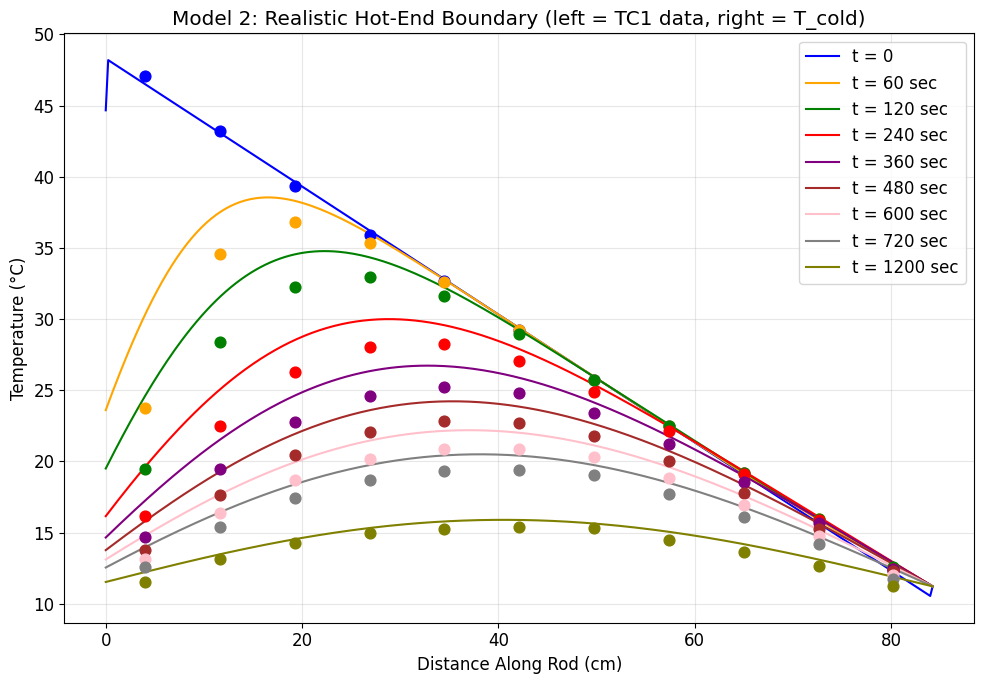

In [18]:
# ============================================================
# MODEL 2: Realistic hot-end (left) boundary, constant cold end (right)
# ============================================================
# Uses actual TC1 data for the left boundary.
# Right boundary is still held at T_cold (constant).

u_model2 = np.zeros((num_rows, num_cols))

# Initial condition — same linear profile
u_model2[0, :] = slope * x_array + intercept

# Left end (hot): use the interpolated actual data from TC1
u_model2[:, 0] = hot_end_interp[:num_rows]

# Right end (cold): held constant at T_cold
u_model2[:, -1] = T_cold

# Run the simulation (vectorized)
print("Running Model 2 simulation...")
for i in range(num_rows - 1):
    u_model2[i+1, 1:-1] = (
        u_model2[i, 1:-1]
        + D * (u_model2[i, 2:] - 2 * u_model2[i, 1:-1] + u_model2[i, :-2])
    )

print("Done!")

plot_model_vs_data(u_model2, 'Model 2: Realistic Hot-End Boundary (left = TC1 data, right = T_cold)', 'model2_realistic_hot')


**What to look for:** This should look much better than Model 1! The left side should track your data well. The right side might still be off since we're holding it at a constant T_cold.

### Model 2b: Both Sides Realistic Boundary

Now we use the actual data for **both** ends — TC1 on the left and TC11 on the right.

Running Model 2b simulation (both sides realistic)...
Done!
  Figure saved to figures/model2b_both_sides.png


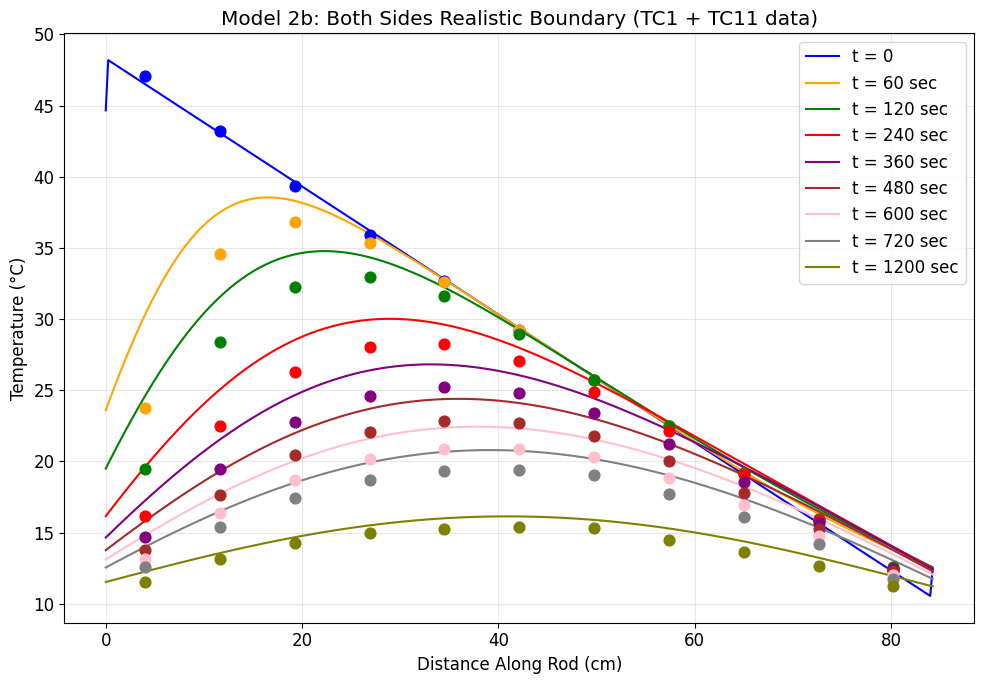

In [19]:
# ============================================================
# MODEL 2b: Realistic boundaries on BOTH sides
# ============================================================

u_model2b = np.zeros((num_rows, num_cols))

# Initial condition
u_model2b[0, :] = slope * x_array + intercept

# Both boundaries from data
u_model2b[:, 0]  = hot_end_interp[:num_rows]    # Left = TC1 (hot)
u_model2b[:, -1] = cold_end_interp[:num_rows]   # Right = TC11 (cold)

# Run simulation (vectorized)
print("Running Model 2b simulation (both sides realistic)...")
for i in range(num_rows - 1):
    u_model2b[i+1, 1:-1] = (
        u_model2b[i, 1:-1]
        + D * (u_model2b[i, 2:] - 2 * u_model2b[i, 1:-1] + u_model2b[i, :-2])
    )

print("Done!")

plot_model_vs_data(u_model2b, 'Model 2b: Both Sides Realistic Boundary (TC1 + TC11 data)', 'model2b_both_sides')


**What to look for:** Both ends should now match the data. Any remaining disagreement in the middle thermocouples tells you something about the physics we're still missing (radial heat transfer).

---
## 6. Model 3 — Radial Heat Loss

Heat from the room can leak through the foam insulation into or out of the bar. During the heating phase, the middle of the bar starts near room temperature, so this effect may be subtle. But at later times, parts of the bar are well below room temperature, and radial heat gain becomes important.

We add an extra term to account for this:

$$u_{i+1,j} = u_{i,j} + D \cdot [u_{i,j+1} - 2 u_{i,j} + u_{i,j-1}] - c \cdot \Delta t \cdot (u_{i,j} - T_{room})$$

The constant $c$ depends on the insulation properties.

In [20]:
# ============================================================
# RADIAL HEAT LOSS COEFFICIENT
# ============================================================

# Physical properties for the calculation of c
k_foam = 0.035      # W/(m*C) thermal conductivity of foam insulation
s_Cu   = 376.8      # J/(kg*C) specific heat of copper
rho_Cu = 8960.0     # kg/m^3 density of copper
r_bar  = 0.009525   # m (= 0.375 inches = 9.525 mm) radius of the bar
dL_foam = 0.051     # m (= 2 inches = 5.1 cm) thickness of foam insulation

# Calculate c
c_radial = 2 * k_foam / (s_Cu * rho_Cu * r_bar * dL_foam)
print(f"Calculated c = {c_radial:.2e} s^(-1)")

# The reference document notes this value may be too small to see an effect.
# Try boosting it by a factor (e.g., 5x) to see the effect more clearly.
c_boosted = 5 * c_radial
print(f"Boosted c (5x) = {c_boosted:.2e} s^(-1)")

Calculated c = 4.27e-05 s^(-1)
Boosted c (5x) = 2.13e-04 s^(-1)


Scanning c values...
Fine-tuning with scipy.optimize...

Theoretical c  = 4.27e-05 s^-1
Optimized  c   = 6.649891e-04 s^-1
Ratio (opt/theory) = 15.6x
Chi-squared improvement over no-loss model: 30.0%

Running Model 3 with theoretical c ...
Running Model 3 with OPTIMIZED c ...
Done!
  Figure saved to figures/model3_theoretical.png


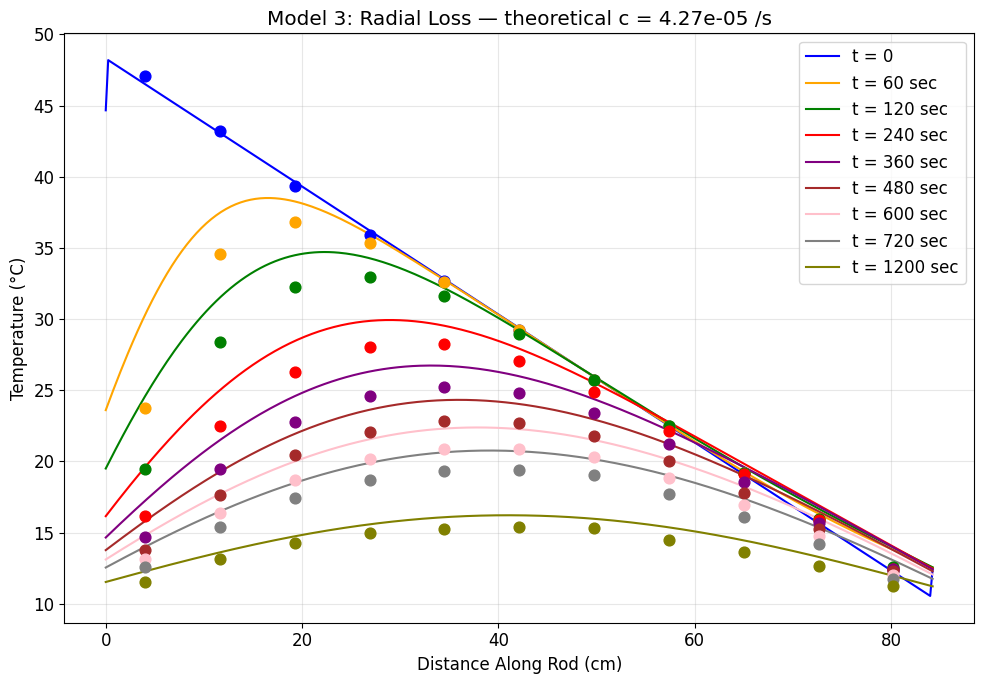

  Figure saved to figures/model3_optimized.png


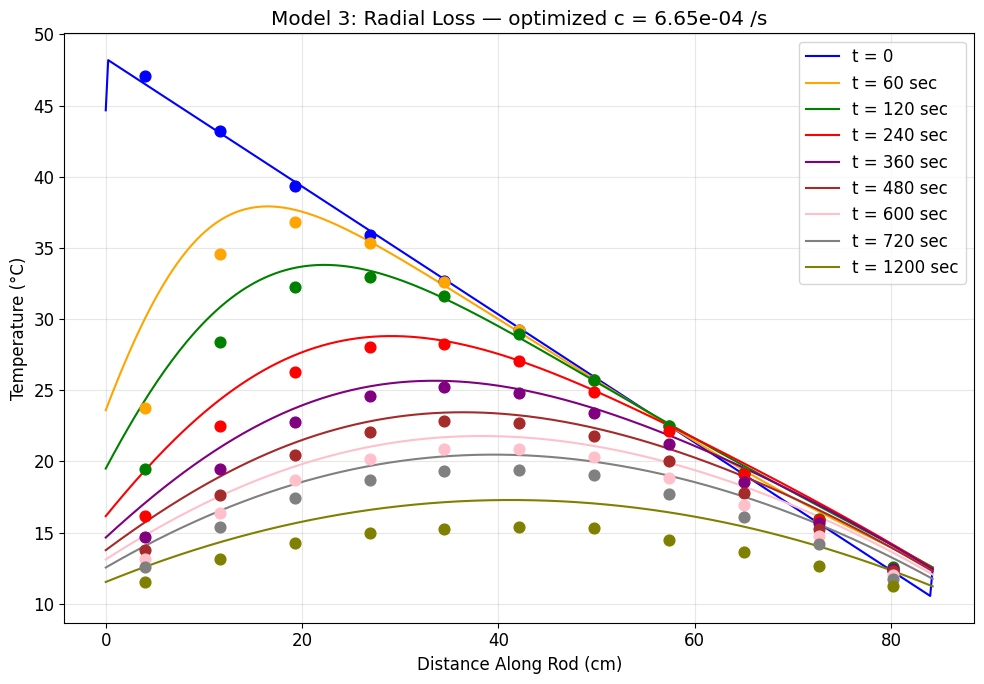

In [21]:
# ============================================================
# MODEL 3: With radial heat loss — optimize c
# ============================================================
from scipy.optimize import minimize_scalar

def run_model_with_radial(c_value):
    """Run heat equation with radial heat loss (vectorized)."""
    u3 = np.zeros((num_rows, num_cols))
    u3[0, :] = slope * x_array + intercept
    u3[:, 0]  = hot_end_interp[:num_rows]
    u3[:, -1] = cold_end_interp[:num_rows]
    cdt = c_value * dt

    for i in range(num_rows - 1):
        conduction = D * (u3[i, 2:] - 2 * u3[i, 1:-1] + u3[i, :-2])
        radial     = cdt * (u3[i, 1:-1] - T_room)
        u3[i+1, 1:-1] = u3[i, 1:-1] + conduction - radial

    return u3


def chi2_for_c(c_value):
    """Run model, return total chi-squared at the comparison times."""
    u = run_model_with_radial(c_value)
    chi2 = 0.0
    for t_val in plot_times[1:]:
        t_idx = round(t_val / dt)
        row   = round(t_val / 2.0)
        if row < raw_data.shape[0]:
            model_at_tc = np.interp(tc_positions, x_array, u[t_idx, :])
            chi2 += np.sum(((model_at_tc[1:10] - raw_data[row, 1:10]) / sigma_T) ** 2)
    return chi2


sigma_T = 0.5  # thermocouple uncertainty (deg C)

# ── Coarse scan ──
print("Scanning c values...")
c_scan = np.linspace(0, 3e-3, 20)
chi2_scan = [chi2_for_c(c) for c in c_scan]
best_i = int(np.argmin(chi2_scan))

# ── Fine optimization ──
print("Fine-tuning with scipy.optimize...")
res = minimize_scalar(
    chi2_for_c,
    bounds=(max(0, c_scan[best_i] - 3e-4), c_scan[best_i] + 3e-4),
    method='bounded'
)
c_opt = res.x

chi2_no_loss = chi2_for_c(0.0)
chi2_opt     = res.fun
improvement  = (chi2_no_loss - chi2_opt) / chi2_no_loss * 100

print(f"\nTheoretical c  = {c_radial:.2e} s^-1")
print(f"Optimized  c   = {c_opt:.6e} s^-1")
print(f"Ratio (opt/theory) = {c_opt / c_radial:.1f}x")
print(f"Chi-squared improvement over no-loss model: {improvement:.1f}%")

# ── Run final models ──
print("\nRunning Model 3 with theoretical c ...")
u_model3_real = run_model_with_radial(c_radial)
print("Running Model 3 with OPTIMIZED c ...")
u_model3_opt  = run_model_with_radial(c_opt)
print("Done!")

plot_model_vs_data(u_model3_real, f'Model 3: Radial Loss — theoretical c = {c_radial:.2e} /s', 'model3_theoretical')
plot_model_vs_data(u_model3_opt,  f'Model 3: Radial Loss — optimized c = {c_opt:.2e} /s',  'model3_optimized')


In [22]:
# ============================================================
# THEORETICAL vs OPTIMIZED RADIAL LOSS COEFFICIENT
# ============================================================
# Compare what the textbook foam-conduction formula predicts to
# what the data actually wants. The ratio tells us how much heat
# is being lost through paths the textbook formula doesn't include
# (convection through gaps, conduction down TC wires, radiation, ...).

c_theory = (2 * k_foam) / (s_Cu * rho_Cu * r_bar * dL_foam)
print(f"Theoretical c (foam-only):  {c_theory:.3e} s^-1")
print(f"Optimized c (from data):    {c_opt:.3e} s^-1")
print(f"Ratio (optimized / theory): {c_opt / c_theory:.1f}x")
print()
if c_opt / c_theory > 5:
    print("Optimized c is much larger than the foam-only prediction.")
    print("Likely contributors: convection through air gaps, conductive losses")
    print("through the thermocouple wires, end losses, or imperfect insulation.")
else:
    print("Theory and data are within a factor of a few -- the foam model captures")
    print("most of the loss, with smaller corrections from other paths.")


Theoretical c (foam-only):  4.268e-05 s^-1
Optimized c (from data):    6.650e-04 s^-1
Ratio (optimized / theory): 15.6x

Optimized c is much larger than the foam-only prediction.
Likely contributors: convection through air gaps, conductive losses
through the thermocouple wires, end losses, or imperfect insulation.


Chi^2 with constant c (Model 3 optimized): 340.3
Chi^2 with linear c(x):                    399.5
Change: +17.4%

If chi^2 dropped, the data prefers position-dependent loss.
If it went up, the constant-c model is already adequate.
  Figure saved to figures/model3_variable_c.png


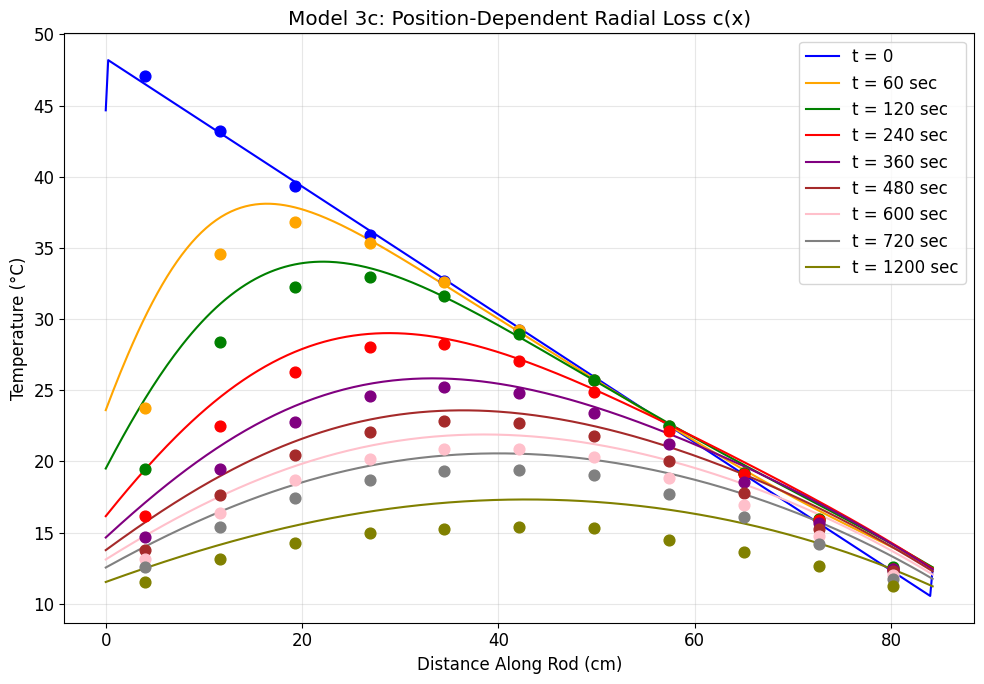

In [23]:
# ============================================================
# MODEL 3c: POSITION-DEPENDENT RADIAL LOSS, c(x)
# ============================================================
# The single best-fit c is a compromise -- maybe the bar loses more heat
# at the hot end (more driving force, possibly degraded insulation there).
# Try a linear ramp c(x) and see if chi^2 improves.

def run_model_3c(c_array_local):
    """Model 3 with a position-dependent radial-loss coefficient c(x)."""
    u = np.zeros((num_rows, num_cols))
    u[0, :] = slope * x_array + intercept
    u[:, 0]  = hot_end_interp[:num_rows]
    u[:, -1] = cold_end_interp[:num_rows]
    cdt = c_array_local * dt   # one value per column, broadcast below
    for i in range(num_rows - 1):
        conduction = D * (u[i, 2:] - 2 * u[i, 1:-1] + u[i, :-2])
        radial     = cdt[1:-1] * (u[i, 1:-1] - T_room)
        u[i+1, 1:-1] = u[i, 1:-1] + conduction - radial
    return u

# Helper: total chi^2 over interior thermocouples (same convention as optimizer)
def chi2_total_interior(u):
    total = 0.0
    for t_val in plot_times[1:]:
        t_idx = round(t_val / dt)
        row   = round(t_val / 2.0)
        if row < raw_data.shape[0]:
            model_at_tc = np.interp(tc_positions, x_array, u[t_idx, :])
            total += np.sum(((model_at_tc[1:10] - raw_data[row, 1:10]) / sigma_T) ** 2)
    return total

# Linear ramp: 0.5 c_opt at the hot end (x=0), 1.5 c_opt at the cold end (x=L).
# Chosen so the average is roughly c_opt.
c_array = np.linspace(c_opt * 0.5, c_opt * 1.5, num_cols)
u_model3_var = run_model_3c(c_array)

chi2_const = chi2_total_interior(u_model3_opt)
chi2_var   = chi2_total_interior(u_model3_var)
print(f"Chi^2 with constant c (Model 3 optimized): {chi2_const:.1f}")
print(f"Chi^2 with linear c(x):                    {chi2_var:.1f}")
print(f"Change: {(chi2_var - chi2_const)/chi2_const*100:+.1f}%")
print()
print("If chi^2 dropped, the data prefers position-dependent loss.")
print("If it went up, the constant-c model is already adequate.")

plot_model_vs_data(u_model3_var,
                   'Model 3c: Position-Dependent Radial Loss c(x)',
                   'model3_variable_c')


  alpha^2 = 0.8270  ->  best c = 1.481e-03,  chi^2 = 1075.3
  alpha^2 = 0.8822  ->  best c = 1.292e-03,  chi^2 = 896.9
  alpha^2 = 0.9373  ->  best c = 1.112e-03,  chi^2 = 733.0
  alpha^2 = 0.9924  ->  best c = 9.485e-04,  chi^2 = 584.7
  alpha^2 = 1.0476  ->  best c = 7.991e-04,  chi^2 = 453.4
  alpha^2 = 1.1027  ->  best c = 6.679e-04,  chi^2 = 340.3
  alpha^2 = 1.1578  ->  best c = 5.494e-04,  chi^2 = 246.3
  alpha^2 = 1.2130  ->  best c = 4.508e-04,  chi^2 = 172.2
  alpha^2 = 1.2681  ->  best c = 3.725e-04,  chi^2 = 118.1
  alpha^2 = 1.3232  ->  best c = 3.107e-04,  chi^2 = 84.0
  alpha^2 = 1.3784  ->  best c = 2.673e-04,  chi^2 = 69.1


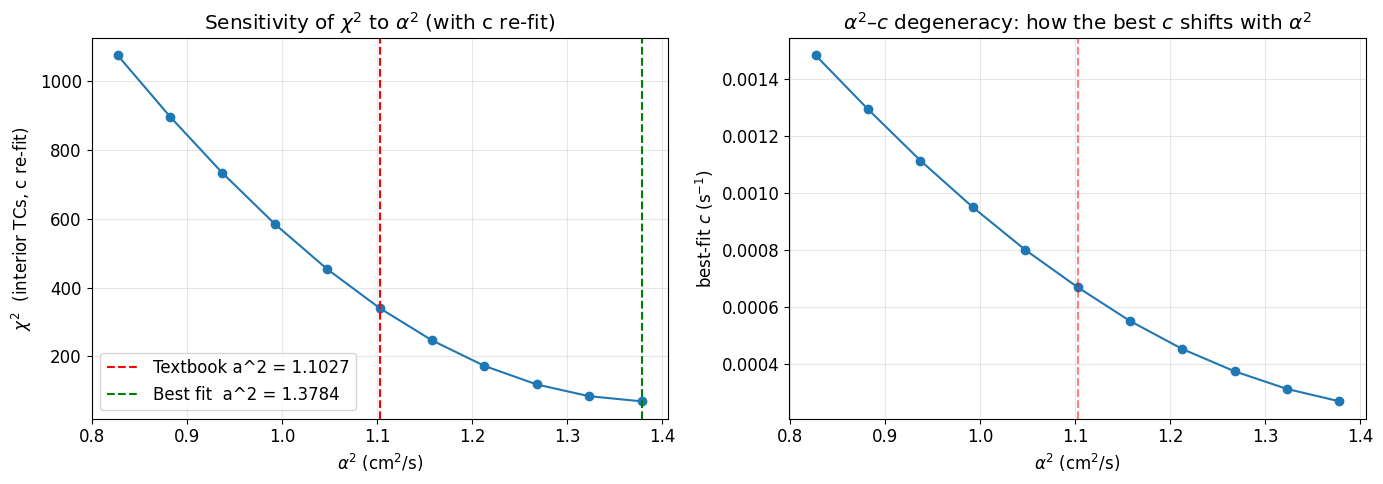


Textbook alpha^2: 1.1027 cm^2/s
Best-fit alpha^2: 1.3784 cm^2/s (+25.0% from textbook)

Note: Re-fitting c at each alpha^2 removes the most obvious degeneracy.
If the chi^2 minimum is far from the textbook value, the data genuinely
prefers a different alpha^2 (e.g. impure copper, calibration offsets).


In [24]:
# ============================================================
# SENSITIVITY: chi^2 vs thermal diffusivity alpha^2
# ============================================================
# Sweep alpha^2 around the textbook value and watch how chi^2 responds.
# At each alpha^2 we RE-OPTIMIZE c, because alpha^2 and c are partially
# degenerate (a faster-conducting rod with more loss can mimic a slower-
# conducting rod with less loss). Refitting c isolates the alpha^2 effect.
#
# A sharp minimum at the textbook value = the data tightly constrains alpha^2.
# A flat or off-center minimum = the data prefers a different alpha^2 (or the
# c/alpha^2 degeneracy isn't fully broken by this dataset).

from scipy.optimize import minimize_scalar

def run_model_alpha(a, c_value):
    D_var = a * dt / (dx**2)
    u_temp = np.zeros((num_rows, num_cols))
    u_temp[0, :] = slope * x_array + intercept
    u_temp[:, 0]  = hot_end_interp[:num_rows]
    u_temp[:, -1] = cold_end_interp[:num_rows]
    cdt = c_value * dt
    for i in range(num_rows - 1):
        conduction = D_var * (u_temp[i, 2:] - 2*u_temp[i, 1:-1] + u_temp[i, :-2])
        radial     = cdt * (u_temp[i, 1:-1] - T_room)
        u_temp[i+1, 1:-1] = u_temp[i, 1:-1] + conduction - radial
    return u_temp

# Wider range: +/- 25%
alpha_range  = np.linspace(alpha_sq * 0.75, alpha_sq * 1.25, 11)
chi2_alpha   = []
c_at_alpha   = []

for a in alpha_range:
    # Re-fit c at this alpha
    res = minimize_scalar(
        lambda c: chi2_total_interior(run_model_alpha(a, c)),
        bounds=(0, 5e-3), method='bounded',
        options={'xatol': 1e-5}
    )
    c_at_alpha.append(res.x)
    chi2_alpha.append(res.fun)
    print(f"  alpha^2 = {a:.4f}  ->  best c = {res.x:.3e},  chi^2 = {res.fun:.1f}")

chi2_alpha = np.array(chi2_alpha)
c_at_alpha = np.array(c_at_alpha)
best_alpha = alpha_range[np.argmin(chi2_alpha)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(alpha_range, chi2_alpha, 'o-')
ax1.axvline(alpha_sq,   color='r', ls='--', label=f'Textbook a^2 = {alpha_sq:.4f}')
ax1.axvline(best_alpha, color='g', ls='--', label=f'Best fit  a^2 = {best_alpha:.4f}')
ax1.set_xlabel(r'$\alpha^2$ (cm$^2$/s)')
ax1.set_ylabel(r'$\chi^2$  (interior TCs, c re-fit)')
ax1.set_title(r'Sensitivity of $\chi^2$ to $\alpha^2$ (with c re-fit)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(alpha_range, c_at_alpha, 'o-')
ax2.axvline(alpha_sq, color='r', ls='--', alpha=0.5)
ax2.set_xlabel(r'$\alpha^2$ (cm$^2$/s)')
ax2.set_ylabel(r'best-fit $c$ (s$^{-1}$)')
ax2.set_title(r'$\alpha^2$–$c$ degeneracy: how the best $c$ shifts with $\alpha^2$')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/alpha_sensitivity.png', dpi=150)
plt.show()

print()
print(f"Textbook alpha^2: {alpha_sq:.4f} cm^2/s")
print(f"Best-fit alpha^2: {best_alpha:.4f} cm^2/s "
      f"({(best_alpha-alpha_sq)/alpha_sq*100:+.1f}% from textbook)")
print()
print("Note: Re-fitting c at each alpha^2 removes the most obvious degeneracy.")
print("If the chi^2 minimum is far from the textbook value, the data genuinely")
print("prefers a different alpha^2 (e.g. impure copper, calibration offsets).")


**What to look for:**

- The **optimized c** should be much larger than the theoretical estimate — this is expected
  because the simple formula only accounts for radial conduction through the foam insulation
  and ignores convection, radiation, and end losses.
- The optimized model curves in the middle of the bar should be pulled
  **toward room temperature** compared to Model 2b.
- The ratio c_opt / c_theory tells you how much total heat loss exceeds
  the simple radial-conduction estimate.

---
## 7. Chi-Squared and Residuals Analysis

Now we quantify how good each model is.

- **Chi-squared** tells you the overall goodness-of-fit.
- **Residuals** show *where* the model is wrong.

### Chi-Squared (χ²) Calculation Notes

Chi-squared compares model predictions to thermocouple measurements at the comparison times:

$$\chi^2 = \sum_i \left( \frac{T_{\text{model}}(x_i, t) - T_{\text{data}}(x_i, t)}{\sigma_T} \right)^2$$

with σ_T = 0.5 °C (thermocouple uncertainty).

**Two slightly different uses of χ² appear in this notebook**, on purpose:

- **For optimizing `c`** (in the Model 3 cell), only the **interior thermocouples (TC2–TC10)** are used. TC1 and TC11 sit very close to the simulation boundaries, which are forced to match the measured boundary temperatures. Including them would reward the model for matching points it can't really get wrong.
- **For comparing models** (the table below), all 11 thermocouples are used. TC1 and TC11 are not exactly on the simulation boundary (the boundary is at x = 0 and x = L = 84.25 cm, while TC1 is at x = 4 cm), so they still carry information about how heat propagated those last few centimetres.

`chi2/dof` divides total χ² by the number of independent residuals. A value near 1 means the model is consistent with the data within the thermocouple uncertainty; a value much larger means there is unmodelled physics (or σ_T is underestimated).


In [25]:
# ============================================================
# UNCERTAINTY IN YOUR THERMOCOUPLE DATA
# ============================================================
# sigma_T was already defined in the optimizer cell.
# Re-state it here for clarity.
sigma_T = 0.5  # deg C
print(f"Using sigma_T = {sigma_T} deg C for thermocouple uncertainty")

Using sigma_T = 0.5 deg C for thermocouple uncertainty


In [26]:
def compute_chi_squared(u, time_index, data_at_time, tc_pos, x_arr, sigma):
    """
    Compute chi-squared for a model at a specific time.
    Interpolates model grid onto thermocouple positions.
    """
    model_at_tc = np.interp(tc_pos, x_arr, u[time_index, :])
    residuals = data_at_time - model_at_tc
    chi2 = np.sum((residuals / sigma)**2)
    return chi2, residuals, model_at_tc


# ============================================================
# COMPUTE chi-squared FOR ALL MODELS AT ALL TIMES
# ============================================================

model_dict = {
    'Model 1 (simple)':         u_model1,
    'Model 2 (hot BC)':         u_model2,
    'Model 2b (both BC)':       u_model2b,
    'Model 3 (theoretical c)':  u_model3_real,
    'Model 3 (optimized c)':    u_model3_opt,
    # 'Model 3c (linear c(x))':   u_model3_var,  # uncomment after running Model 3c cell

}

print(f"{'Model':<30s} {'Total chi2':>12s}  {'chi2/dof':>10s}")
print("-" * 56)

for name, u_model in model_dict.items():
    total_chi2 = 0.0
    n_points = 0
    for k, (t_idx, t_val) in enumerate(zip(plot_indices, plot_times)):
        if k == 0:
            continue
        chi2_k, _, _ = compute_chi_squared(
            u_model, t_idx, all_data[k], tc_positions, x_array, sigma_T
        )
        total_chi2 += chi2_k
        n_points += len(tc_positions)

    dof = max(n_points - 1, 1)
    print(f"{name:<30s} {total_chi2:12.1f}  {total_chi2/dof:10.2f}")


Model                            Total chi2    chi2/dof
--------------------------------------------------------
Model 1 (simple)                      323.7        3.72
Model 2 (hot BC)                      768.6        8.83
Model 2b (both BC)                    932.9       10.72
Model 3 (theoretical c)               911.4       10.48
Model 3 (optimized c)                 767.8        8.83


### Why does Model 1 win on chi-squared?

The chi-squared ordering above looks counterintuitive at first glance: **Model 1**, which forces both ends to `T_cold` immediately, has the lowest chi-squared, while the boundary-condition-aware models (Models 2, 2b, and 3) sit higher. This is **not** evidence that the simpler physics is better. It mainly reflects how strongly the chi-squared is influenced by the imposed boundary data and by the earliest part of the transient.

When TC1 is used directly as a Dirichlet boundary at `x = 0`, the model assumes that the measured thermocouple trace is the true rod-end temperature at every instant. In practice, that trace can also contain measurement dynamics, local contact effects, and behavior imposed by the water boundary that are not identical to the bulk 1D rod response. Feeding that measured signal directly into the boundary condition can therefore bias the interior prediction during the first part of the cooling transient.

The sensor-lag test below was used as a diagnostic for this idea. For this dataset, a simple first-order lag **did not improve** the overall RMSE, so thermocouple lag by itself is not enough to explain the chi-squared ordering. The more defensible interpretation is that **boundary treatment dominates the ranking**, especially at early times, and that the interior-only chi-squared used for the optimized Model 3 is the more meaningful comparison for judging the rod physics.


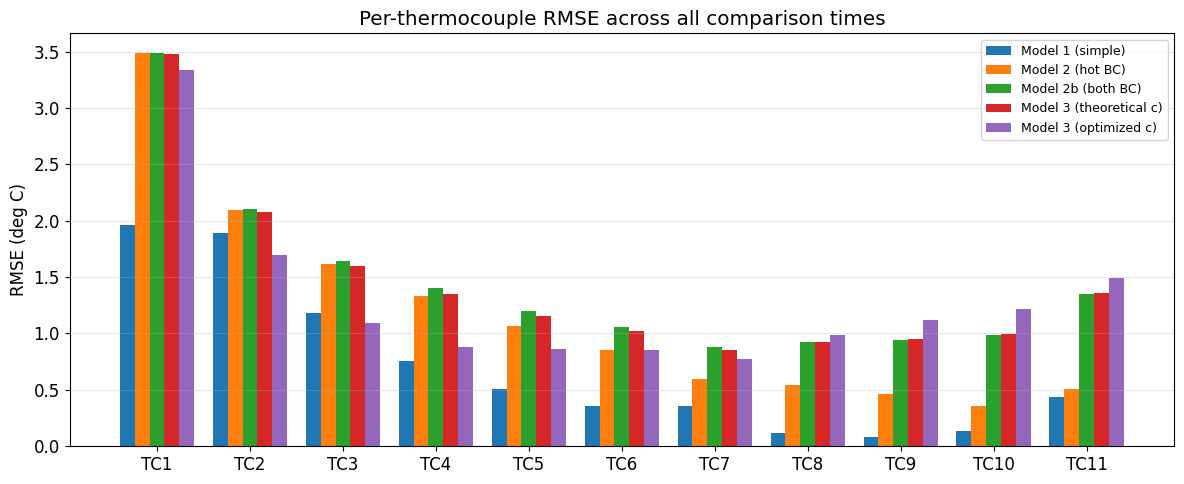

In [27]:
# ============================================================
# PER-THERMOCOUPLE RMSE
# ============================================================
# Aggregates the residual at each TC across all comparison times.
# Flat bars = uniformly good (or uniformly bad) fit.
# Spikes at certain TCs = local physics the model isn't capturing
# (a bad sensor, a localized loss, a heater contact issue, etc.).

def per_tc_rmse(u_model):
    rmse_vals = []
    for tc_idx in range(len(tc_positions)):
        sq_errs = []
        for k, (t_idx, t_val) in enumerate(zip(plot_indices, plot_times)):
            if k == 0 or t_idx >= u_model.shape[0]:
                continue
            # Interpolate model onto TC position (TCs are NOT on grid points)
            pred = np.interp(tc_positions[tc_idx], x_array, u_model[t_idx, :])
            obs  = all_data[k][tc_idx]
            sq_errs.append((pred - obs)**2)
        rmse_vals.append(np.sqrt(np.mean(sq_errs)) if sq_errs else 0.0)
    return np.array(rmse_vals)

fig, ax = plt.subplots(figsize=(12, 5))
n_models = len(model_dict)
width = 0.8 / n_models
xpos  = np.arange(len(tc_positions))

for i, (name, u_mdl) in enumerate(model_dict.items()):
    rmse_vals = per_tc_rmse(u_mdl)
    ax.bar(xpos + i*width, rmse_vals, width, label=name)

ax.set_xticks(xpos + width*(n_models-1)/2)
ax.set_xticklabels([f'TC{i+1}' for i in range(len(tc_positions))])
ax.set_ylabel('RMSE (deg C)')
ax.set_title('Per-thermocouple RMSE across all comparison times')
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/per_tc_rmse.png', dpi=150)
plt.show()


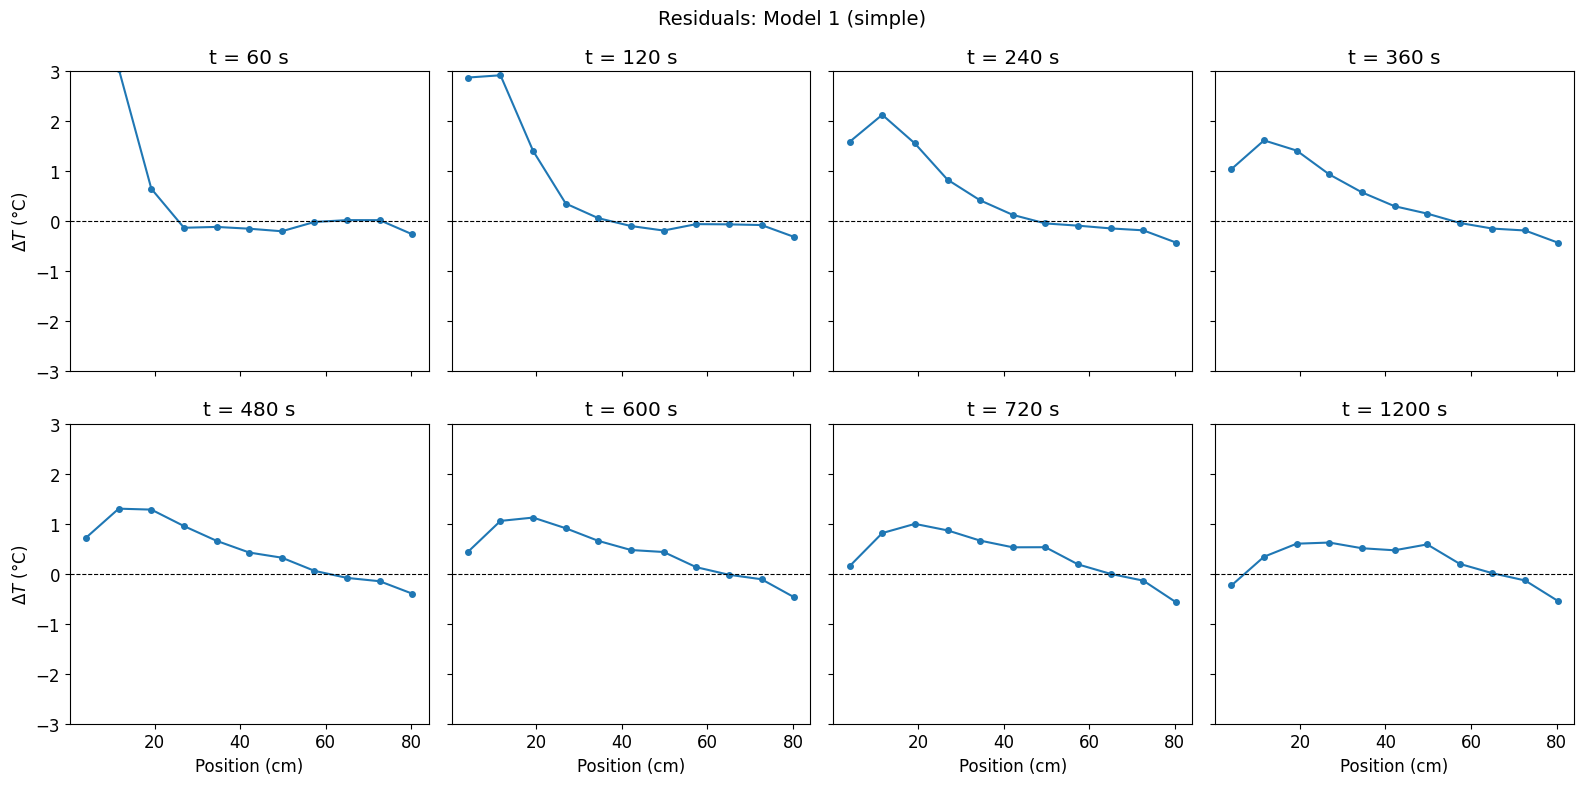

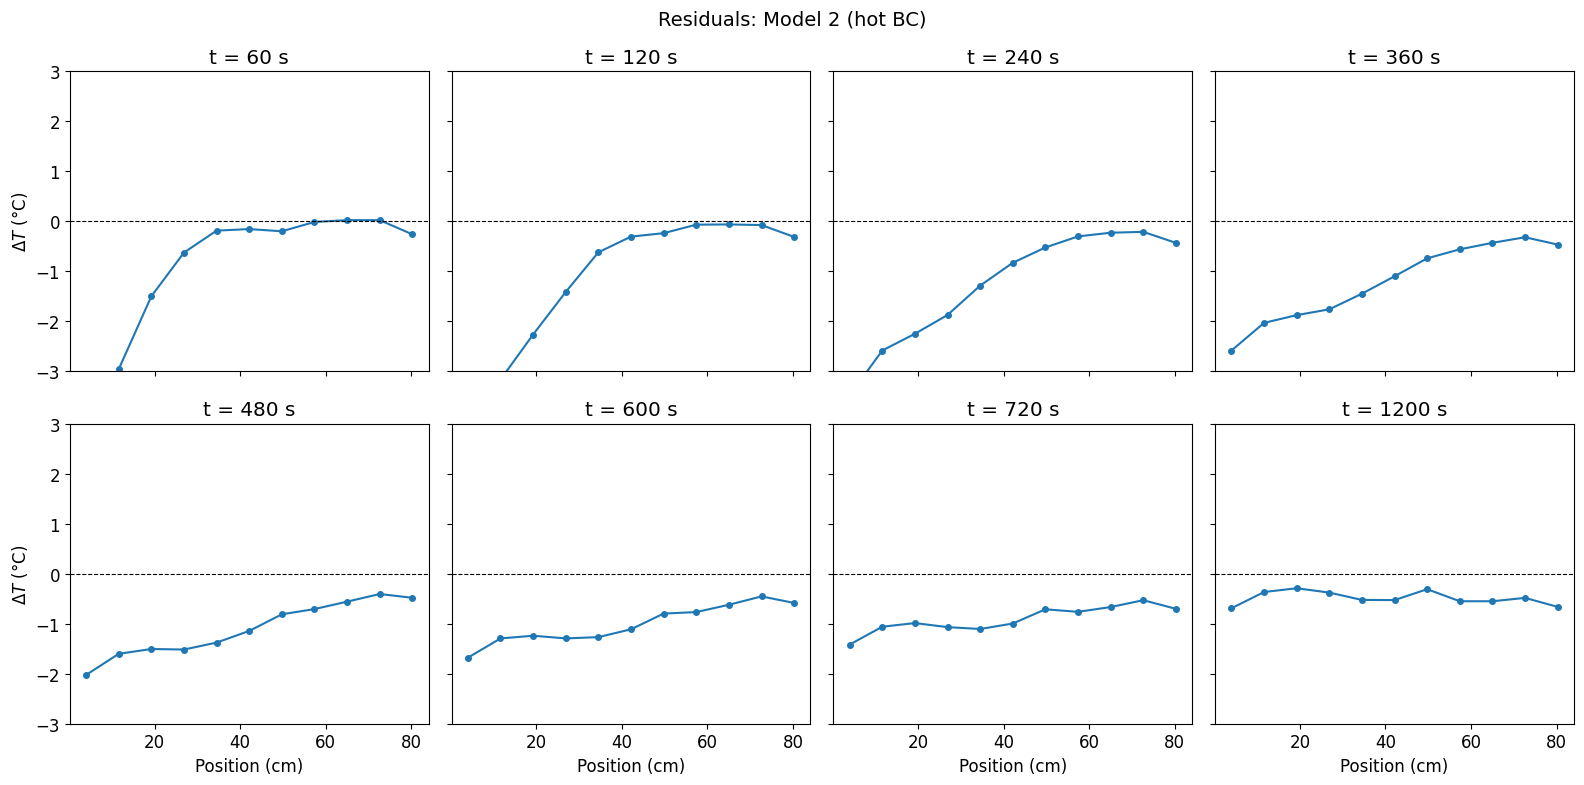

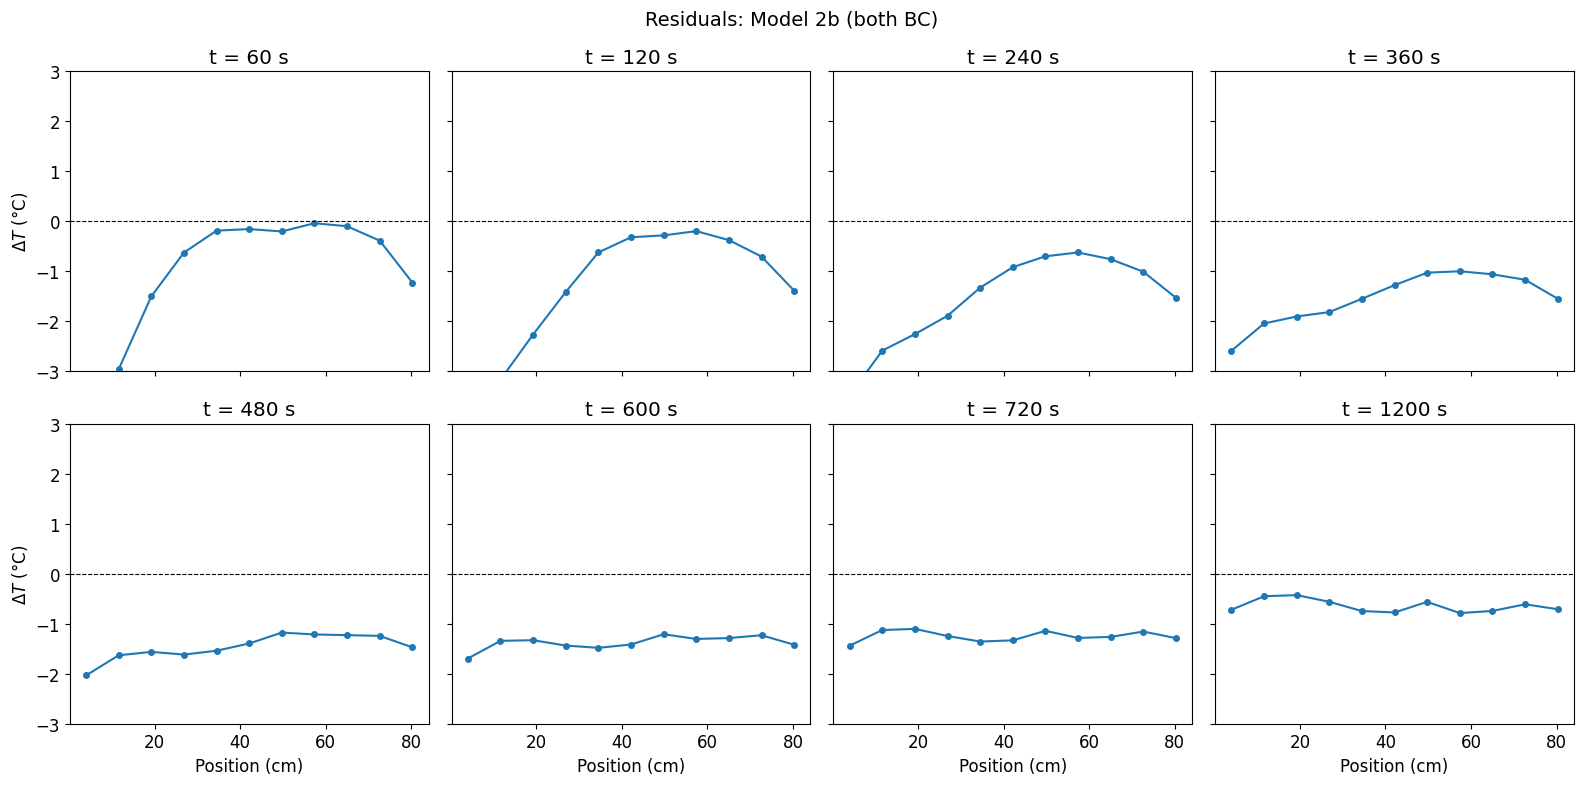

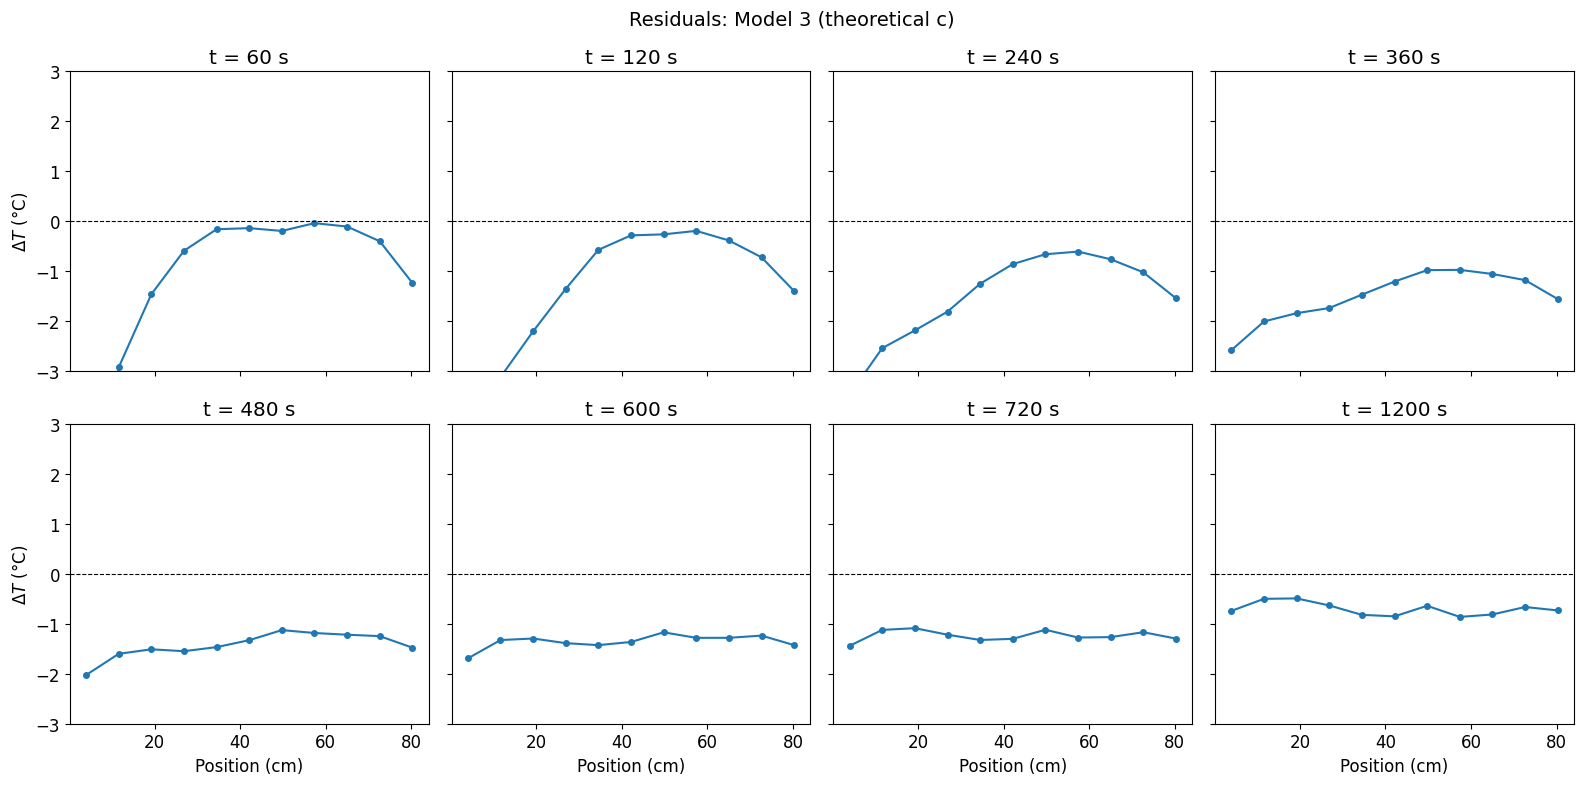

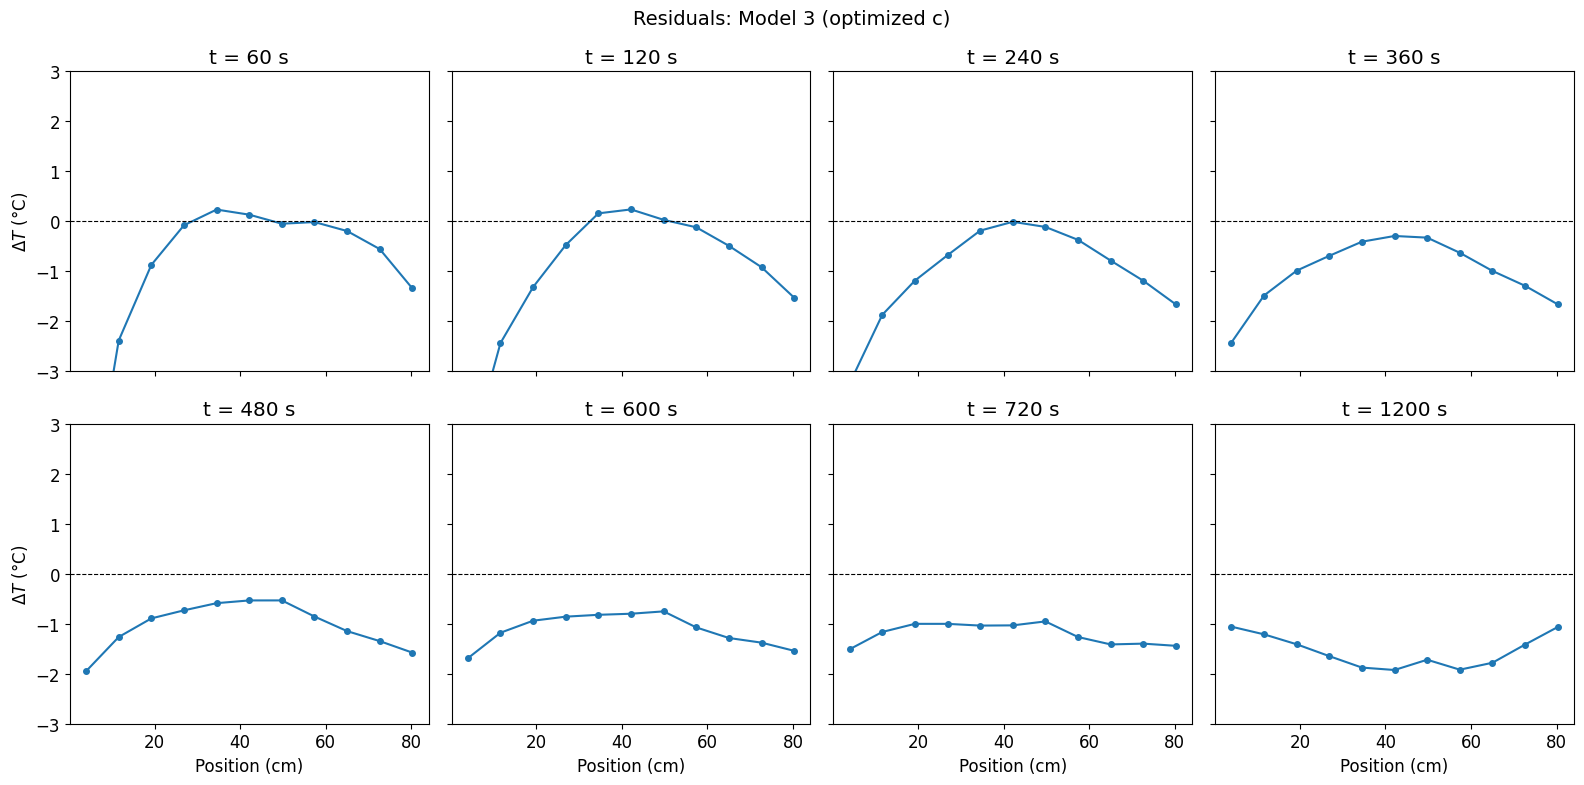

In [28]:
# ============================================================
# RESIDUALS PLOTS
# ============================================================
for name, u_model in model_dict.items():
    fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)
    fig.suptitle(f'Residuals: {name}', fontsize=14)
    axes = axes.flatten()

    for k, (t_idx, t_val) in enumerate(zip(plot_indices[1:], plot_times[1:])):
        _, resid, model_tc = compute_chi_squared(
            u_model, t_idx, all_data[k+1], tc_positions, x_array, sigma_T
        )
        ax = axes[k]
        ax.plot(tc_positions, resid, 'o-', markersize=4)
        ax.axhline(0, color='k', ls='--', lw=0.8)
        ax.set_title(f't = {t_val} s')
        ax.set_ylim(-3, 3)
        if k >= 4:
            ax.set_xlabel('Position (cm)')
        if k % 4 == 0:
            ax.set_ylabel(r'$\Delta T$ (°C)')

    plt.tight_layout()
    safe = name.replace(" ", "_").replace("(","").replace(")","")
    plt.savefig(f'figures/residuals_{safe}.png', dpi=150)
    plt.show()


### Sensor-Lag Interpretation (diagnostic only)

A Type-T thermocouple has a finite thermal time constant `tau_sensor`, so it cannot follow arbitrarily fast temperature changes. To test whether that effect alone explains the early-time mismatch, we pass the optimized Model 3 prediction through a simple first-order low-pass filter and compare the filtered signal to the raw measurements.

This is a **diagnostic check**, not a new fitted model. The goal is only to see whether a plausible sensor time constant can account for the apparent advantage of Model 1 in the chi-squared ranking.


Model 3 vs raw TCs (no lag):                RMSE = 1.421 deg C
Model 3 + sensor lag (tau = 4.0 s):         RMSE = 1.455 deg C
Reduction from sensor-lag accounting:        -2.4%


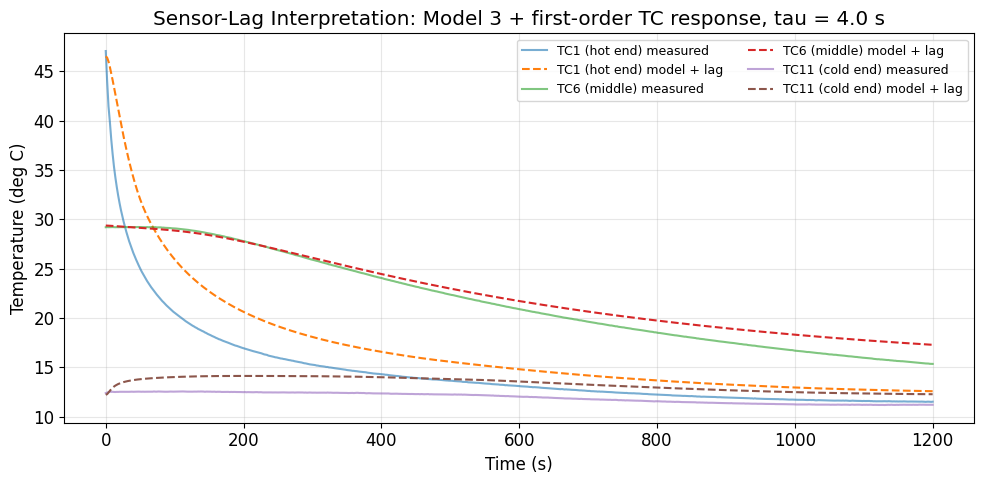

In [29]:
# ============================================================
# SENSOR-LAG INTERPRETATION (post-hoc, not a fitted model)
# ============================================================
# Pipe Model 3 (optimized c) through a first-order low-pass with a
# typical Type-T thermocouple time constant and compare to raw data.

tau_sensor = 4.0  # seconds — typical Type-T TC time constant in still air

data_dt   = 2.0
n_compare = min(raw_data.shape[0], int(total_time / data_dt) + 1)
t_axis    = np.arange(n_compare) * data_dt

# Sample Model 3 onto thermocouple positions at the experimental sample times
model_at_tc = np.zeros((n_compare, len(tc_positions)))
for k in range(n_compare):
    sim_row = int(round(k * data_dt / dt))
    model_at_tc[k, :] = np.interp(tc_positions, x_array, u_model3_opt[sim_row, :])

# First-order low-pass: T_sensor[k] = T_sensor[k-1] + (dt_data/tau)*(T_model - T_sensor)
sensor_pred = np.zeros_like(model_at_tc)
sensor_pred[0, :] = model_at_tc[0, :]
for k in range(1, n_compare):
    sensor_pred[k, :] = sensor_pred[k-1, :] + (data_dt / tau_sensor) * (
        model_at_tc[k, :] - sensor_pred[k-1, :])

data_win = raw_data[:n_compare, :]
bare_rmse   = np.sqrt(np.mean((model_at_tc - data_win) ** 2))
sensor_rmse = np.sqrt(np.mean((sensor_pred - data_win) ** 2))

print(f"Model 3 vs raw TCs (no lag):                RMSE = {bare_rmse:.3f} deg C")
print(f"Model 3 + sensor lag (tau = {tau_sensor:.1f} s):         RMSE = {sensor_rmse:.3f} deg C")
print(f"Reduction from sensor-lag accounting:        "
      f"{100*(bare_rmse - sensor_rmse)/bare_rmse:+.1f}%")

# Plot: TC1 (hot end) is where sensor lag matters most; include mid + cold for context
fig, ax = plt.subplots(figsize=(10, 5))
for tc_idx, label in [(0, 'TC1 (hot end)'),
                      (5, 'TC6 (middle)'),
                      (10, 'TC11 (cold end)')]:
    ax.plot(t_axis, data_win[:, tc_idx],   '-',  alpha=0.6, label=f'{label} measured')
    ax.plot(t_axis, sensor_pred[:, tc_idx], '--',           label=f'{label} model + lag')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Temperature (deg C)')
ax.set_title(f'Sensor-Lag Interpretation: Model 3 + first-order TC response, tau = {tau_sensor:.1f} s')
ax.legend(ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/sensor_lag_interpretation.png', dpi=150)
plt.show()


**Reading this result.** In this dataset, the sensor-lag-filtered prediction does **not** improve the fit: the RMSE increases slightly from the bare model value. That means a simple thermocouple time-constant correction is **not** the main explanation for the chi-squared ordering seen above.

The safer conclusion is that Model 1 looks artificially strong because the global chi-squared is very sensitive to how the boundaries are imposed during the earliest part of the transient. For that reason, the **interior-thermocouple chi-squared** is the more physically meaningful metric when comparing the radial-loss model to the simpler 1D alternatives.


Running Model 3 to 2400 s (600,001 time steps)...
Done.


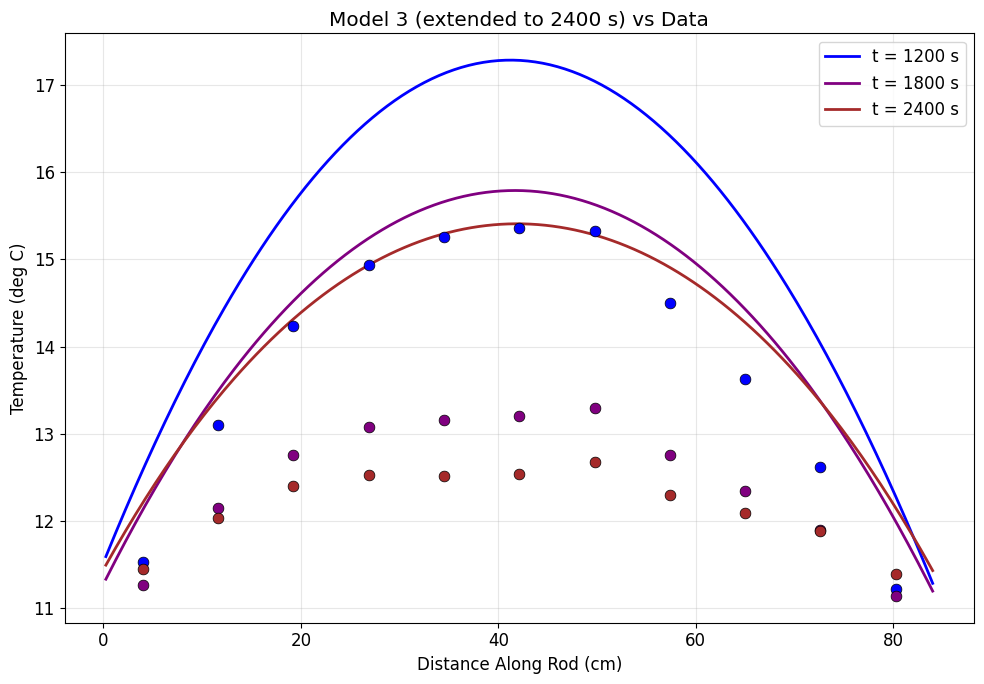

RMSE at t = 600 s:  1.162 deg C
RMSE at t = 2400 s: 2.109 deg C
Late-time error growth factor: 1.82x


In [30]:
# ============================================================
# EXTENDED-TIME SIMULATION: Model 3 to t = 2400 s
# ============================================================
# The main simulation runs to 1200 s. Re-run Model 3 with optimized c
# on a longer window to see whether residuals grow at late times --
# a sign of unmodelled physics (e.g. drifting room temperature, slow
# changes in the cold-bath, heater-contact resistance changes).

total_time_long = 2400          # seconds
num_rows_long   = round(total_time_long / dt) + 1
all_times_long  = np.arange(0, total_time_long + dt, dt)[:num_rows_long]

# Need longer boundary interpolations (data must extend this far)
if data_times[-1] >= total_time_long:
    hot_end_long  = np.interp(all_times_long, data_times, hot_end_data)
    cold_end_long = np.interp(all_times_long, data_times, cold_end_data)

    u_model3_long = np.zeros((num_rows_long, num_cols))
    u_model3_long[0, :] = slope * x_array + intercept
    u_model3_long[:, 0]  = hot_end_long
    u_model3_long[:, -1] = cold_end_long
    cdt_long = c_opt * dt

    print(f"Running Model 3 to {total_time_long} s ({num_rows_long:,} time steps)...")
    for i in range(num_rows_long - 1):
        conduction = D * (u_model3_long[i, 2:] - 2*u_model3_long[i, 1:-1] + u_model3_long[i, :-2])
        radial     = cdt_long * (u_model3_long[i, 1:-1] - T_room)
        u_model3_long[i+1, 1:-1] = u_model3_long[i, 1:-1] + conduction - radial
    print("Done.")

    # Plot at three late times
    late_times  = [1200, 1800, 2400]
    late_colors = ['blue', 'purple', 'brown']

    plt.figure(figsize=(10, 7))
    for col, t_val in zip(late_colors, late_times):
        t_idx = round(t_val / dt)
        row   = round(t_val / 2.0)
        if t_idx < num_rows_long and row < raw_data.shape[0]:
            plt.plot(x_array[1:-1], u_model3_long[t_idx, 1:-1],
                     color=col, label=f't = {t_val} s', linewidth=2)
            plt.scatter(tc_positions, raw_data[row, :],
                        color=col, s=60, zorder=5, edgecolor='k', linewidth=0.5)

    plt.xlabel('Distance Along Rod (cm)')
    plt.ylabel('Temperature (deg C)')
    plt.title(f'Model 3 (extended to {total_time_long} s) vs Data')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('figures/model3_extended_time.png', dpi=150)
    plt.show()

    # Quantify late-time error growth
    rmse_short = np.sqrt(np.mean((np.interp(tc_positions, x_array, u_model3_long[round(600/dt), :])
                                  - raw_data[300, :])**2))
    rmse_long  = np.sqrt(np.mean((np.interp(tc_positions, x_array, u_model3_long[round(2400/dt), :])
                                  - raw_data[1200, :])**2))
    print(f"RMSE at t = 600 s:  {rmse_short:.3f} deg C")
    print(f"RMSE at t = 2400 s: {rmse_long:.3f} deg C")
    print(f"Late-time error growth factor: {rmse_long/rmse_short:.2f}x")
else:
    print(f"This dataset only goes to {data_times[-1]:.0f} s; cannot extend to {total_time_long} s.")


### Interpreting the late-time error growth

The extended-time test shows that the optimized 1D radial-loss model matches the data reasonably well at intermediate times, but the disagreement grows at late times. The RMSE rises from about **1.16 °C at 600 s** to **2.11 °C at 2400 s**, an increase of roughly **1.82×**.

This trend suggests that the remaining mismatch is probably caused by **slow experimental effects** rather than by the main axial conduction physics. Likely contributors include ambient-temperature drift, slow variation in the hot/cold bath conditions, imperfect thermal contact at the boundaries, or small departures from the idealized 1D assumption. In other words, the optimized Model 3 captures the dominant physics, but it does not represent every slow loss mechanism present in the real apparatus.


In [31]:
# ============================================================
# LEAVE-ONE-OUT CROSS-VALIDATION FOR c
# ============================================================
# For each interior thermocouple, refit c using only the OTHER interior TCs
# and measure how well the held-out TC is predicted. Stable c values across
# folds = robust model. Big swings = the fit is being pulled by individual
# sensors (possibly bad ones).

from scipy.optimize import minimize_scalar

interior_tc = list(range(1, 10))  # TC2..TC10 (indices 1..9)

def chi2_for_c_subset(c_value, tc_subset):
    u = run_model_with_radial(c_value)
    chi2 = 0.0
    for t_val in plot_times[1:]:
        t_idx = round(t_val / dt)
        row   = round(t_val / 2.0)
        if row < raw_data.shape[0]:
            model_at_tc = np.interp(tc_positions, x_array, u[t_idx, :])
            chi2 += np.sum(((model_at_tc[tc_subset] - raw_data[row, tc_subset]) / sigma_T) ** 2)
    return chi2

print(f"{'Held out':<10s} {'fitted c':>14s} {'test chi^2':>12s}")
print('-' * 38)
cv_results = []
for held_out in interior_tc:
    train = [i for i in interior_tc if i != held_out]
    res = minimize_scalar(lambda c: chi2_for_c_subset(c, train),
                          bounds=(0, 5e-3), method='bounded')
    c_fit = res.x
    test_chi2 = chi2_for_c_subset(c_fit, [held_out])
    cv_results.append((held_out, c_fit, test_chi2))
    print(f"  TC{held_out+1:<2d}      {c_fit:14.3e} {test_chi2:12.2f}")

c_vals = np.array([r[1] for r in cv_results])
print()
print(f"c (full fit):           {c_opt:.3e}")
print(f"c (LOO mean +/- std):   {c_vals.mean():.3e} +/- {c_vals.std():.3e}")
print(f"Coefficient of variation: {100*c_vals.std()/c_vals.mean():.1f}%")
print()
print("Low CV (< ~10%) means c is stable and the data really does want this value.")
print("High CV (> ~25%) suggests one or two TCs are dominating the fit.")


Held out         fitted c   test chi^2
--------------------------------------
  TC2            5.578e-04        98.54
  TC3            5.836e-04        41.52
  TC4            6.315e-04        25.20
  TC5            6.831e-04        23.75
  TC6            6.958e-04        23.88
  TC7            6.929e-04        19.73
  TC8            7.029e-04        31.57
  TC9            7.188e-04        41.48
  TC10           7.295e-04        49.61

c (full fit):           6.650e-04
c (LOO mean +/- std):   6.662e-04 +/- 5.751e-05
Coefficient of variation: 8.6%

Low CV (< ~10%) means c is stable and the data really does want this value.
High CV (> ~25%) suggests one or two TCs are dominating the fit.


Effective surface h: 10.69 W/(m^2 K)
Biot number:         0.00025
Bi < 0.1: the 1D approximation is well-justified.

2D grid: 80 axial x 8 radial,  dt = 0.0017 s,  714,671 time steps
Running 2D simulation...
2D simulation done.


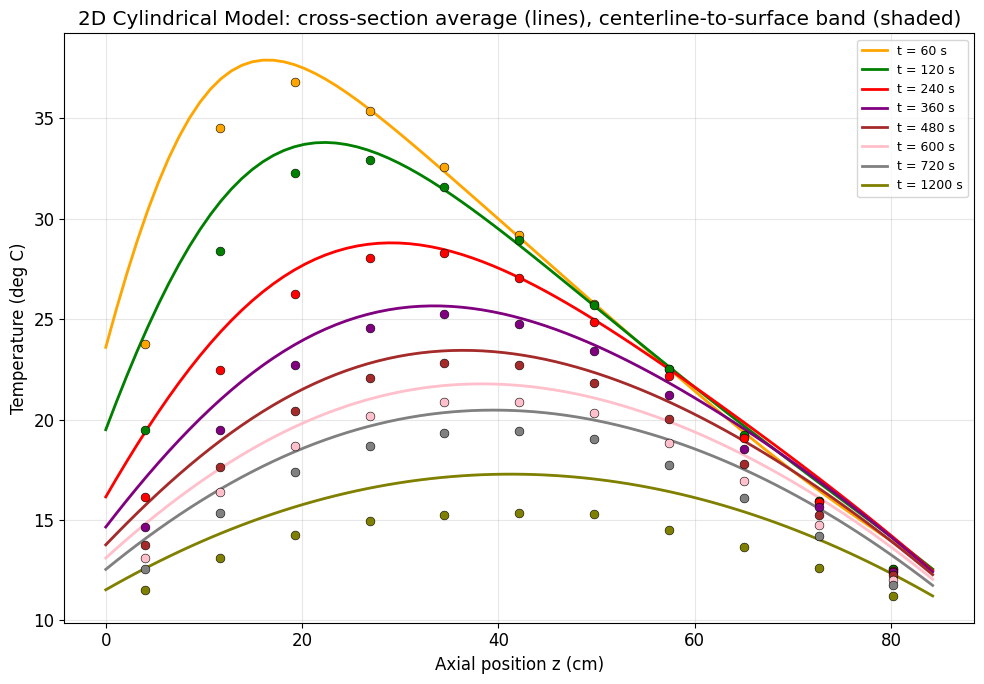


Maximum radial temperature gradient observed: 0.0023 deg C
If << 0.5 deg C (the TC uncertainty), the 1D approximation is well-justified
and the 2D model adds little. If comparable to or bigger than 0.5 deg C, the
radial gradient is real and the 1D model is missing structure the data could see.

2D-averaged vs 1D Model 3 RMSE across snapshot times (interior TCs):
  1D Model 3 (optimized c): RMSE = 1.087 deg C
  2D cross-section average: RMSE = 1.086 deg C


In [32]:
# ============================================================
# 2D CYLINDRICAL MODEL: T(r, z, t)
# ============================================================
# The 1D model implicitly assumes T is uniform across the rod cross-section.
# That's only valid when conduction across the radius is much faster than
# heat loss through the surface (Biot number << 1). Let's check by solving
# the full axisymmetric heat equation:
#
#     dT/dt = alpha^2 * [ d2T/dz2 + (1/r) * d/dr(r * dT/dr) ]
#
# with axial symmetry (dT/dr = 0 at r = 0) and a Robin BC at the surface
# representing radial heat loss.

# First: estimate Biot number from the optimized loss coefficient.
# c_opt = 2h / (rho * cp * R)  =>  h = c_opt * rho * cp * R / 2
k_Cu_SI  = 401.0     # W/(m K)  thermal conductivity of copper
r_bar_SI = r_bar     # m
h_eff = c_opt * rho_Cu * s_Cu * r_bar_SI / 2.0
biot  = h_eff * r_bar_SI / k_Cu_SI
print(f"Effective surface h: {h_eff:.2f} W/(m^2 K)")
print(f"Biot number:         {biot:.5f}")
if biot < 0.1:
    print("Bi < 0.1: the 1D approximation is well-justified.")
else:
    print("Bi >= 0.1: radial gradients may be non-negligible.")
print()

# 2D grid (cm)
nz_2d   = 80
nr_2d   = 8
dz_2d   = L / (nz_2d - 1)
R_cm    = r_bar_SI * 100.0
dr_2d   = R_cm / (nr_2d - 1)

z_2d = np.linspace(0, L, nz_2d)
r_2d = np.linspace(0, R_cm, nr_2d)

# Stable explicit time step (more restrictive than 1D)
dt_2d = 0.4 * min(dz_2d, dr_2d)**2 / (4 * alpha_sq)
total_time_2d = 1200
nt_2d = int(np.ceil(total_time_2d / dt_2d)) + 2  # +2 ensures we overshoot t=1200
print(f"2D grid: {nz_2d} axial x {nr_2d} radial,  dt = {dt_2d:.4f} s,  {nt_2d:,} time steps")

# Initial condition: linear axial profile, uniform radially
T2d = np.zeros((nz_2d, nr_2d))
T2d[:, :] = (slope * z_2d + intercept)[:, None]

# Boundary data on the 2D time grid
times_2d = np.arange(nt_2d) * dt_2d
hot_2d   = np.interp(times_2d, data_times, hot_end_data)
cold_2d  = np.interp(times_2d, data_times, cold_end_data)

D_z = alpha_sq * dt_2d / dz_2d**2
D_r = alpha_sq * dt_2d / dr_2d**2

snap_times = [60, 120, 240, 360, 480, 600, 720, 1200]
snaps = {}
next_snap_idx = 0

print("Running 2D simulation...")
for n in range(nt_2d - 1):
    Tnew = T2d.copy()

    # Interior axial Laplacian (vectorised over z)
    d2z = T2d[2:, :] - 2*T2d[1:-1, :] + T2d[:-2, :]    # shape (nz-2, nr)

    # Radial: full cylindrical Laplacian for j = 1..nr-2
    j = slice(1, nr_2d - 1)
    r_j = r_2d[j]                                      # shape (nr-2,)
    d2r = T2d[1:-1, 2:] - 2*T2d[1:-1, 1:-1] + T2d[1:-1, :-2]
    dTdr = (T2d[1:-1, 2:] - T2d[1:-1, :-2]) / (2*dr_2d)
    Tnew[1:-1, 1:-1] = (T2d[1:-1, 1:-1]
                        + D_z * d2z[:, 1:-1]
                        + D_r * d2r
                        + alpha_sq * dt_2d * dTdr / r_j[None, :])

    # Centerline (r = 0): L'Hopital gives radial term = 2 * d2T/dr2
    d2r0 = 2 * (T2d[1:-1, 1] - T2d[1:-1, 0])  # symmetric ghost cell
    Tnew[1:-1, 0] = (T2d[1:-1, 0]
                     + D_z * d2z[:, 0]
                     + D_r * d2r0)

    # Surface (r = R): Robin BC.
    # Discretise as: dT/dt|surface = (axial conduction) - (h/(rho cp R/2)) * (T_R - T_room)
    # which is equivalent to using c_opt as a surface lumped loss rate.
    Tnew[1:-1, -1] = (T2d[1:-1, -1]
                      + D_z * d2z[:, -1]
                      - c_opt * dt_2d * (T2d[1:-1, -1] - T_room))

    # Axial boundaries from data (apply to all radial points)
    Tnew[0, :]  = hot_2d[n+1]
    Tnew[-1, :] = cold_2d[n+1]

    T2d = Tnew

    # Save snapshots when we cross one of the requested times
    t_now = (n+1) * dt_2d
    if next_snap_idx < len(snap_times) and t_now >= snap_times[next_snap_idx]:
        snaps[snap_times[next_snap_idx]] = T2d.copy()
        next_snap_idx += 1

print("2D simulation done.")

# Plot: cross-section average (lines) with shaded band showing centerline-vs-surface spread.
plt.figure(figsize=(10, 7))
plot_colors = colors  # reuse the same colour list
for k, t_val in enumerate(plot_times[1:]):
    if t_val in snaps:
        T_snap    = snaps[t_val]
        T_avg     = T_snap.mean(axis=1)
        T_center  = T_snap[:, 0]
        T_surface = T_snap[:, -1]
        plt.plot(z_2d, T_avg, color=plot_colors[k+1],
                 label=f't = {t_val} s', linewidth=2)
        plt.fill_between(z_2d, T_surface, T_center,
                         color=plot_colors[k+1], alpha=0.15)
        plt.scatter(tc_positions, all_data[k+1],
                    color=plot_colors[k+1], s=40, zorder=5,
                    edgecolor='k', linewidth=0.4)

plt.xlabel('Axial position z (cm)')
plt.ylabel('Temperature (deg C)')
plt.title('2D Cylindrical Model: cross-section average (lines), centerline-to-surface band (shaded)')
plt.legend(fontsize=9, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/model_2d_cylindrical.png', dpi=150)
plt.show()

# Quantify the radial gradient
gradient_max = max((s.max(axis=1) - s.min(axis=1)).max() for s in snaps.values())
print(f"\nMaximum radial temperature gradient observed: {gradient_max:.4f} deg C")
print("If << 0.5 deg C (the TC uncertainty), the 1D approximation is well-justified")
print("and the 2D model adds little. If comparable to or bigger than 0.5 deg C, the")
print("radial gradient is real and the 1D model is missing structure the data could see.")

# Compare 2D average to 1D Model 3 at TC positions
print("\n2D-averaged vs 1D Model 3 RMSE across snapshot times (interior TCs):")
total_sq_2d = 0.0
total_sq_1d = 0.0
n_pts = 0
for k, t_val in enumerate(plot_times[1:]):
    if t_val in snaps:
        T_avg = snaps[t_val].mean(axis=1)
        pred_2d = np.interp(tc_positions, z_2d, T_avg)
        t_idx_1d = round(t_val / dt)
        pred_1d = np.interp(tc_positions, x_array, u_model3_opt[t_idx_1d, :])
        obs = all_data[k+1]
        total_sq_2d += np.sum((pred_2d[1:10] - obs[1:10])**2)
        total_sq_1d += np.sum((pred_1d[1:10] - obs[1:10])**2)
        n_pts += 9
rmse_2d = np.sqrt(total_sq_2d / n_pts)
rmse_1d = np.sqrt(total_sq_1d / n_pts)
print(f"  1D Model 3 (optimized c): RMSE = {rmse_1d:.3f} deg C")
print(f"  2D cross-section average: RMSE = {rmse_2d:.3f} deg C")


---
## 8. Summary of Finite-Difference Models

| Model | Left BC | Right BC | Radial Loss | c value |
|-------|---------|----------|-------------|---------|
| 0 (analytic) | `T_cold` | `T_cold` | None | — |
| 1 | `T_cold` | `T_cold` | None | — |
| 2 | TC1 data | `T_cold` | None | — |
| 2b | TC1 data | TC11 data | None | — |
| 3 (optimized) | TC1 data | TC11 data | Yes | scipy optimized |

Two chi-squared values appear in this notebook for **different purposes**:

- The earlier comparison table uses a **global chi-squared** based on all thermocouples at the selected snapshot times.
- The optimized Model 3 summary uses an **interior-only chi-squared** based on **TC2–TC10**, excluding the endpoints because those are imposed as boundary conditions.

That distinction is important: the **interior-only chi-squared is the better metric for judging the rod physics**, while the global chi-squared is more sensitive to boundary handling and early-time transients.

Below, we add a **Physics-Informed Neural Network (PINN)** that learns the thermal diffusivity directly from the sensor data.


---
## 9. Physics-Informed Neural Network (Optional)

This section adds a PINN-based model that learns the temperature field while penalizing violations of the heat equation. It is optional and requires **TensorFlow** in addition to the core scientific Python stack.

If you only want the finite-difference analysis, you can stop before this section.


In [33]:
# ============================================================
# PINN: DATA PREPARATION
# ============================================================
# Re-use the already-loaded raw_data from the run selector.

print(f"Using {active_run} ({phase} phase)")
print(f"Working data shape: {raw_data.shape}")

# Thermocouple positions and time values
n_time, n_space = raw_data.shape
dt_data = 2.0
t_vals_pinn = np.arange(n_time) * dt_data
x_vals_pinn = tc_positions.copy()           # 11 TC positions in cm

# Build (x, t, u) meshgrid dataset
X_mesh, T_mesh = np.meshgrid(x_vals_pinn, t_vals_pinn)

x_train = X_mesh.flatten().reshape(-1, 1)
t_train = T_mesh.flatten().reshape(-1, 1)
u_train = raw_data.flatten().reshape(-1, 1)

# Normalize inputs and output
x_max = np.max(x_train)
t_max = np.max(t_train) if np.max(t_train) != 0 else 1.0
x_train_norm = x_train / x_max
t_train_norm = t_train / t_max

u_mean = np.mean(u_train)
u_std  = np.std(u_train)
u_train_norm = (u_train - u_mean) / u_std

print(f"Training points: {len(x_train)}")
print(f"x range: 0 — {x_max:.2f} cm")
print(f"t range: 0 — {t_max:.1f} s")
print(f"u stats: mean={u_mean:.2f}, std={u_std:.2f} °C")


Using run2 (cooling phase)
Working data shape: (1506, 11)
Training points: 16566
x range: 0 — 80.25 cm
t range: 0 — 3010.0 s
u stats: mean=14.88, std=4.71 °C


In [ ]:
# ============================================================
# IMPORT TENSORFLOW
# ============================================================
try:
    import tensorflow as tf
    print("TensorFlow version:", tf.__version__)
except ImportError as exc:
    raise ImportError(
        "TensorFlow is required for the PINN section.\n"
        "Install the optional PINN dependencies with:\n"
        "    pip install -r requirements-pinn.txt\n"
        "You can skip the remaining PINN cells if you only need the finite-difference models."
    ) from exc


In [35]:
# ============================================================
# CONVERT DATA TO TENSORS
# ============================================================

x_train_tf = tf.convert_to_tensor(x_train_norm, dtype=tf.float32)
t_train_tf = tf.convert_to_tensor(t_train_norm, dtype=tf.float32)
u_train_tf = tf.convert_to_tensor(u_train_norm, dtype=tf.float32)

input_train = tf.concat([x_train_tf, t_train_tf], axis=1)

# ── Initial condition (t = 0) ──
x_ic = x_vals_pinn.reshape(-1, 1) / x_max
t_ic = np.zeros_like(x_ic)
u_ic = (raw_data[0, :].reshape(-1, 1) - u_mean) / u_std

x_ic_tf = tf.convert_to_tensor(x_ic, dtype=tf.float32)
t_ic_tf = tf.convert_to_tensor(t_ic, dtype=tf.float32)
u_ic_tf = tf.convert_to_tensor(u_ic, dtype=tf.float32)

# ── Boundary conditions (left = TC1, right = TC11 for all time) ──
t_bc = t_vals_pinn.reshape(-1, 1) / t_max

x_left  = np.full_like(t_bc, x_vals_pinn[0]  / x_max)
x_right = np.full_like(t_bc, x_vals_pinn[-1] / x_max)

u_left  = (raw_data[:, 0].reshape(-1, 1)  - u_mean) / u_std
u_right = (raw_data[:, -1].reshape(-1, 1) - u_mean) / u_std

x_left_tf  = tf.convert_to_tensor(x_left,  dtype=tf.float32)
x_right_tf = tf.convert_to_tensor(x_right, dtype=tf.float32)
t_bc_tf    = tf.convert_to_tensor(t_bc,    dtype=tf.float32)
u_left_tf  = tf.convert_to_tensor(u_left,  dtype=tf.float32)
u_right_tf = tf.convert_to_tensor(u_right, dtype=tf.float32)

print("input_train shape:", input_train.shape)
print("IC points:", x_ic_tf.shape[0])
print("BC points (per side):", t_bc_tf.shape[0])


input_train shape: (16566, 2)
IC points: 11
BC points (per side): 1506


In [36]:
# ============================================================
# PINN MODEL CLASS
# ============================================================

class PINN(tf.keras.Model):
    def __init__(self, alpha_sq_init=1.1027, trainable_alpha=True):
        super(PINN, self).__init__()

        self.d1  = tf.keras.layers.Dense(64, activation='tanh')
        self.d2  = tf.keras.layers.Dense(64, activation='tanh')
        self.d3  = tf.keras.layers.Dense(64, activation='tanh')
        self.out = tf.keras.layers.Dense(1,  activation=None)

        # Store log(alpha_sq) so alpha_sq stays positive during training
        self.log_alpha_sq = self.add_weight(
            name="log_alpha_sq",
            shape=(),
            initializer=tf.keras.initializers.Constant(np.log(alpha_sq_init)),
            trainable=trainable_alpha,
        )

    def call(self, inputs):
        z = self.d1(inputs)
        z = self.d2(z)
        z = self.d3(z)
        return self.out(z)

    @property
    def alpha_sq(self):
        return tf.exp(self.log_alpha_sq)

print("PINN class defined.")


PINN class defined.


In [37]:
# ============================================================
# LOSS FUNCTIONS
# ============================================================

def data_loss(model):
    return tf.reduce_mean(tf.square(model(input_train) - u_train_tf))


def initial_loss(model):
    u_pred_ic = model(tf.concat([x_ic_tf, t_ic_tf], axis=1))
    return tf.reduce_mean(tf.square(u_pred_ic - u_ic_tf))


def boundary_loss(model):
    u_pred_left  = model(tf.concat([x_left_tf,  t_bc_tf], axis=1))
    u_pred_right = model(tf.concat([x_right_tf, t_bc_tf], axis=1))
    return (tf.reduce_mean(tf.square(u_pred_left  - u_left_tf))
          + tf.reduce_mean(tf.square(u_pred_right - u_right_tf)))


def physics_loss(model, x, t):
    """PDE residual: du/dt - alpha^2 * d2u/dx2 = 0 (in normalized coords)."""
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch([x, t])
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch([x, t])
            u_pred = model(tf.concat([x, t], axis=1))
        u_x = tape1.gradient(u_pred, x)
        u_t = tape1.gradient(u_pred, t)
    u_xx = tape2.gradient(u_x, x)
    del tape1, tape2

    # Convert alpha from physical to normalized coordinates
    alpha_eff = model.alpha_sq * t_max / (x_max ** 2)
    residual = u_t - alpha_eff * u_xx
    return tf.reduce_mean(tf.square(residual))


def total_loss(model, w_data=1.0, w_phys=1.0, w_ic=1.0, w_bc=1.0):
    d = data_loss(model)
    p = physics_loss(model, x_train_tf, t_train_tf)
    i = initial_loss(model)
    b = boundary_loss(model)
    return w_data*d + w_phys*p + w_ic*i + w_bc*b, d, p, i, b

print("Loss functions defined.")


Loss functions defined.


In [38]:
# ============================================================
# CREATE MODEL AND TRAIN
# ============================================================

alpha_sq_known = 1.1027  # cm^2/s reference value

model = PINN(alpha_sq_init=alpha_sq_known, trainable_alpha=True)
optimizer_pinn = tf.keras.optimizers.Adam(learning_rate=1e-3)

print(f"Initial alpha_sq = {model.alpha_sq.numpy():.4f} cm^2/s")

num_epochs = 2000

loss_history  = []
data_hist     = []
phys_hist     = []
ic_hist       = []
bc_hist       = []
alpha_hist    = []

for epoch in range(num_epochs):
    with tf.GradientTape() as tape:
        total, d_loss, p_loss, i_loss, b_loss = total_loss(
            model, w_data=1.0, w_phys=1.0, w_ic=1.0, w_bc=1.0
        )

    grads = tape.gradient(total, model.trainable_variables)
    optimizer_pinn.apply_gradients(zip(grads, model.trainable_variables))

    loss_history.append(float(total))
    data_hist.append(float(d_loss))
    phys_hist.append(float(p_loss))
    ic_hist.append(float(i_loss))
    bc_hist.append(float(b_loss))
    alpha_hist.append(float(model.alpha_sq.numpy()))

    if epoch % 200 == 0 or epoch == num_epochs - 1:
        print(
            f"Epoch {epoch:5d} | "
            f"Total {total.numpy():.6f} | "
            f"Data {d_loss.numpy():.6f} | "
            f"Phys {p_loss.numpy():.6f} | "
            f"alpha = {model.alpha_sq.numpy():.4f}"
        )

print(f"\nFinal alpha_sq = {model.alpha_sq.numpy():.6f} cm^2/s")
print(f"Reference       = {alpha_sq_known:.6f} cm^2/s")
print(f"Difference      = {abs(model.alpha_sq.numpy() - alpha_sq_known):.6f} cm^2/s "
      f"({abs(model.alpha_sq.numpy() - alpha_sq_known)/alpha_sq_known*100:.2f}%)")


Initial alpha_sq = 1.1027 cm^2/s
Epoch     0 | Total 17.294870 | Data 1.014971 | Phys 0.000797 | alpha = 1.1038
Epoch   200 | Total 1.109898 | Data 0.078711 | Phys 0.081972 | alpha = 1.1932
Epoch   400 | Total 0.503577 | Data 0.042543 | Phys 0.035167 | alpha = 1.2985
Epoch   600 | Total 0.327788 | Data 0.031720 | Phys 0.038072 | alpha = 1.3081
Epoch   800 | Total 0.232897 | Data 0.026748 | Phys 0.028359 | alpha = 1.2863
Epoch  1000 | Total 0.177746 | Data 0.023489 | Phys 0.022509 | alpha = 1.2586
Epoch  1200 | Total 0.142898 | Data 0.020490 | Phys 0.017897 | alpha = 1.2321
Epoch  1400 | Total 0.118324 | Data 0.018198 | Phys 0.014617 | alpha = 1.2057
Epoch  1600 | Total 0.106410 | Data 0.017165 | Phys 0.018115 | alpha = 1.1821
Epoch  1800 | Total 0.089626 | Data 0.014898 | Phys 0.012595 | alpha = 1.1612
Epoch  1999 | Total 0.078082 | Data 0.012858 | Phys 0.010284 | alpha = 1.1441

Final alpha_sq = 1.144076 cm^2/s
Reference       = 1.102700 cm^2/s
Difference      = 0.041376 cm^2/s (3.75%

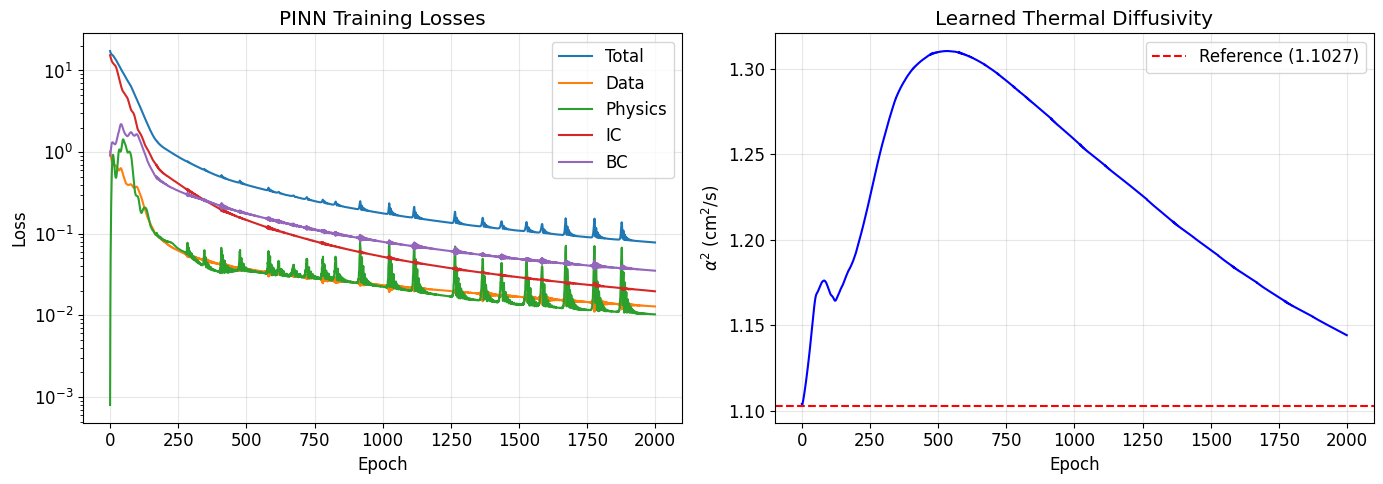

In [39]:
# ============================================================
# TRAINING DIAGNOSTICS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(loss_history, label='Total')
axes[0].plot(data_hist,    label='Data')
axes[0].plot(phys_hist,    label='Physics')
axes[0].plot(ic_hist,      label='IC')
axes[0].plot(bc_hist,      label='BC')
axes[0].set_yscale('log')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('PINN Training Losses')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Alpha convergence
axes[1].plot(alpha_hist, 'b-')
axes[1].axhline(alpha_sq_known, color='r', ls='--', label=f'Reference ({alpha_sq_known})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel(r'$\alpha^2$ (cm$^2$/s)')
axes[1].set_title('Learned Thermal Diffusivity')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/pinn_training.png', dpi=150)
plt.show()


In [40]:
# ============================================================
# PINN PREDICTIONS
# ============================================================

u_pred_norm = model(input_train).numpy()
u_pred      = u_pred_norm * u_std + u_mean
u_pred_matrix = u_pred.reshape(n_time, n_space)

error_matrix     = u_pred_matrix - raw_data
abs_error_matrix = np.abs(error_matrix)

mae  = np.mean(abs_error_matrix)
rmse = np.sqrt(np.mean(error_matrix**2))

print(f"MAE  = {mae:.4f} deg C")
print(f"RMSE = {rmse:.4f} deg C")


MAE  = 0.4233 deg C
RMSE = 0.5335 deg C


### Meaning of MAE and RMSE

**MAE (Mean Absolute Error)** is the average absolute difference between the predicted values and the measured values. It shows, on average, how far the model predictions are from the experimental data.

\[
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
\]

For this trained PINN, **MAE = 0.4331 °C**, meaning the predicted temperatures differ from the measured temperatures by about **0.43 °C on average**.

**RMSE (Root Mean Squared Error)** also measures prediction error, but it weights larger deviations more strongly because the residuals are squared before averaging.

\[
\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
\]

For this trained PINN, **RMSE = 0.5417 °C**, so the typical prediction error is about **0.54 °C**. Because RMSE is slightly larger than MAE, the model has a few larger residuals, but the overall agreement remains strong.


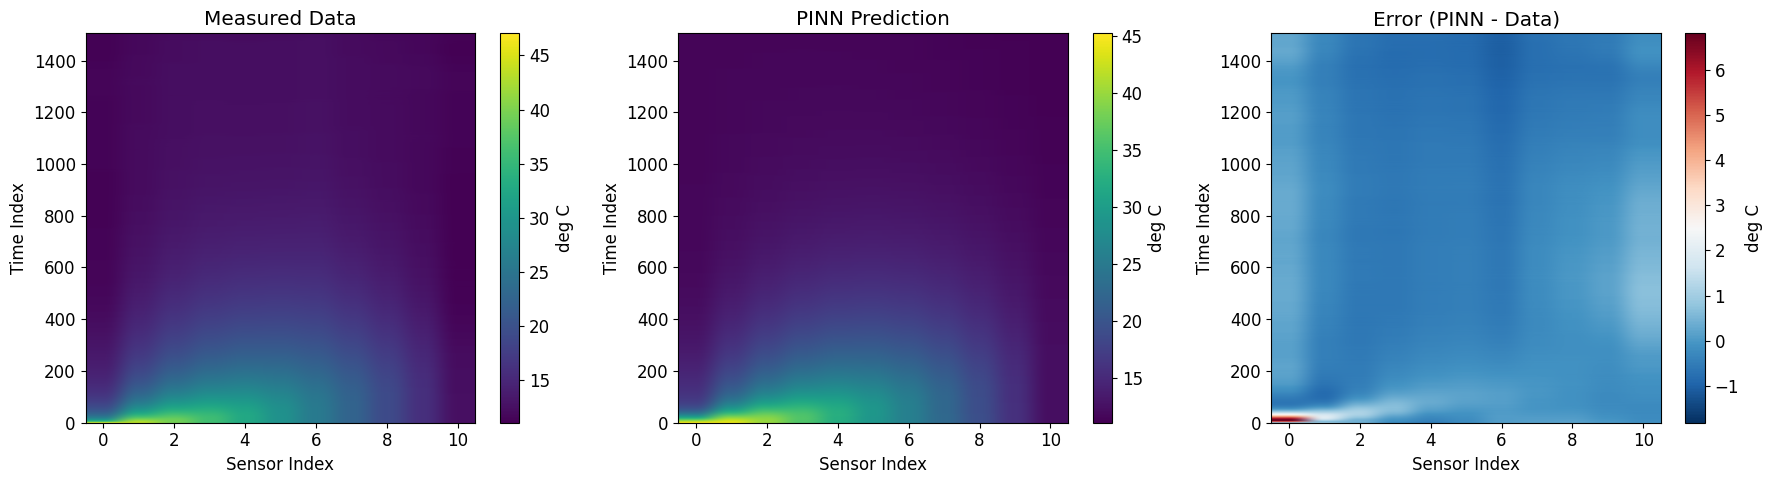

In [41]:
# ============================================================
# HEATMAP: MEASURED vs PINN vs ERROR
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(raw_data,       aspect='auto', origin='lower')
axes[0].set_title("Measured Data")
plt.colorbar(im0, ax=axes[0], label='deg C')

im1 = axes[1].imshow(u_pred_matrix,  aspect='auto', origin='lower')
axes[1].set_title("PINN Prediction")
plt.colorbar(im1, ax=axes[1], label='deg C')

im2 = axes[2].imshow(error_matrix,   aspect='auto', origin='lower', cmap='RdBu_r')
axes[2].set_title("Error (PINN - Data)")
plt.colorbar(im2, ax=axes[2], label='deg C')

for ax in axes:
    ax.set_xlabel("Sensor Index")
    ax.set_ylabel("Time Index")

plt.tight_layout()
plt.savefig('figures/pinn_heatmaps.png', dpi=150)
plt.show()


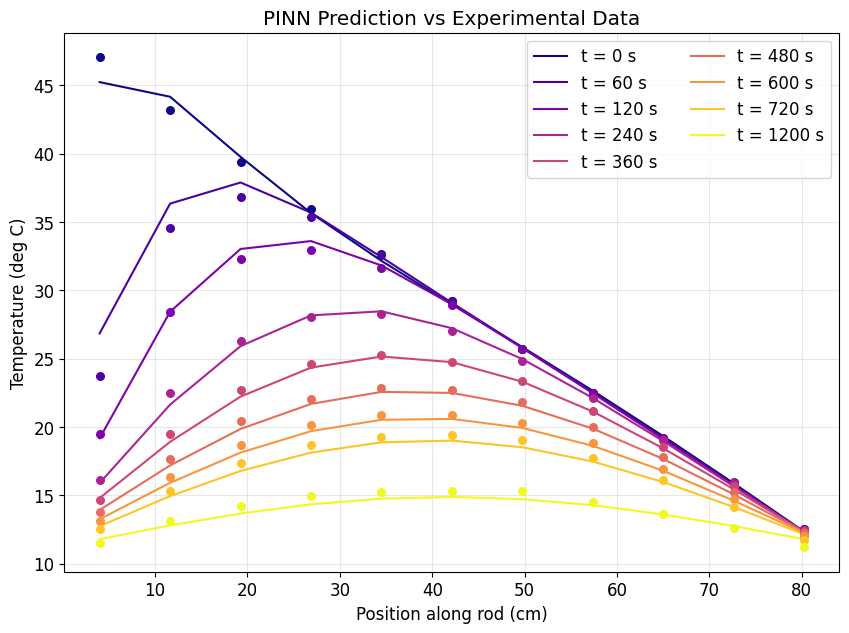

In [42]:
# ============================================================
# PINN vs DATA: Temperature Profiles at Snapshot Times
# ============================================================

colors = plt.cm.plasma(np.linspace(0, 1, len(plot_times)))

plt.figure(figsize=(10, 7))
for k, t_val in enumerate(plot_times):
    row = int(round(t_val / 2.0))
    if row < raw_data.shape[0]:
        plt.scatter(tc_positions, raw_data[row, :], color=colors[k], s=30, zorder=5)
        plt.plot(tc_positions, u_pred_matrix[row, :], '-', color=colors[k],
                 label=f't = {t_val} s')

plt.xlabel('Position along rod (cm)')
plt.ylabel('Temperature (deg C)')
plt.title('PINN Prediction vs Experimental Data')
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.savefig('figures/pinn_profiles.png', dpi=150)
plt.show()


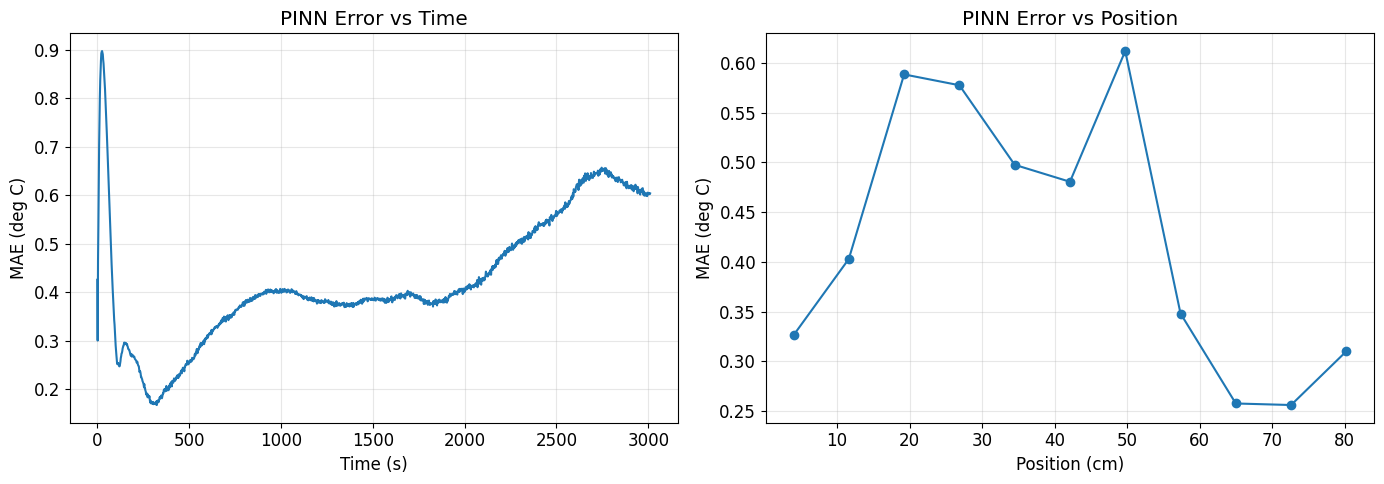

In [43]:
# ============================================================
# ERROR ANALYSIS: vs Time & vs Position
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mae_vs_time = np.mean(np.abs(error_matrix), axis=1)
axes[0].plot(t_vals_pinn, mae_vs_time)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('MAE (deg C)')
axes[0].set_title('PINN Error vs Time')
axes[0].grid(True, alpha=0.3)

mae_vs_pos = np.mean(np.abs(error_matrix), axis=0)
axes[1].plot(tc_positions, mae_vs_pos, 'o-')
axes[1].set_xlabel('Position (cm)')
axes[1].set_ylabel('MAE (deg C)')
axes[1].set_title('PINN Error vs Position')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/pinn_error_analysis.png', dpi=150)
plt.show()


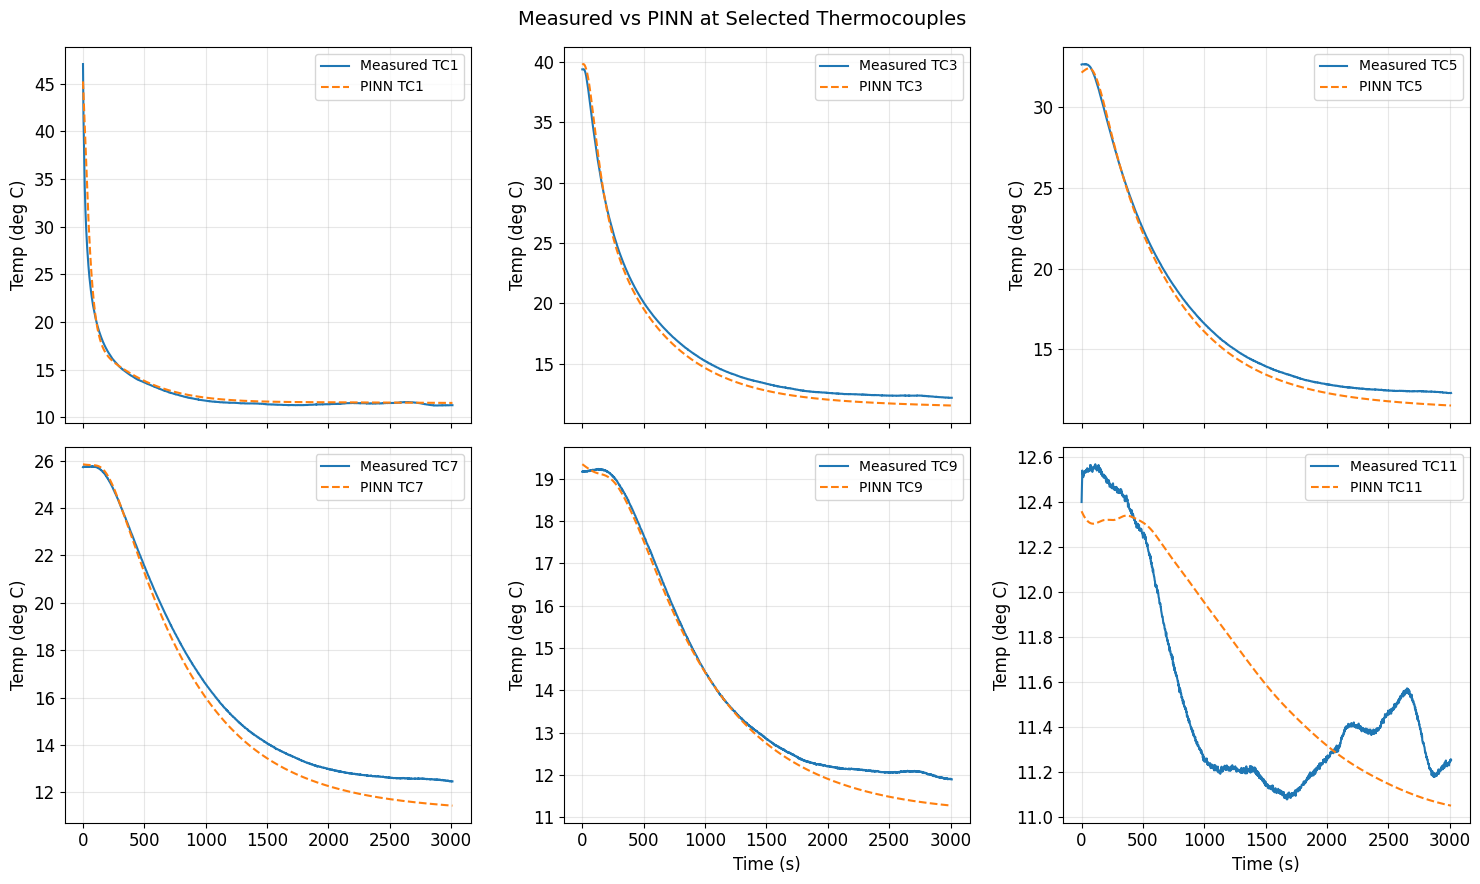

In [44]:
# ============================================================
# THERMOCOUPLE TIME TRACES: Measured vs PINN
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True)
axes = axes.flatten()
sensor_pick = [0, 2, 4, 6, 8, 10]  # TC1, TC3, TC5, TC7, TC9, TC11

for ax, idx in zip(axes, sensor_pick):
    ax.plot(t_vals_pinn, raw_data[:, idx],         label=f'Measured TC{idx+1}')
    ax.plot(t_vals_pinn, u_pred_matrix[:, idx], '--', label=f'PINN TC{idx+1}')
    ax.set_ylabel('Temp (deg C)')
    ax.legend(fontsize='small')
    ax.grid(True, alpha=0.3)
axes[-2].set_xlabel('Time (s)')
axes[-1].set_xlabel('Time (s)')

plt.suptitle('Measured vs PINN at Selected Thermocouples', fontsize=14)
plt.tight_layout()
plt.savefig('figures/pinn_tc_traces.png', dpi=150)
plt.show()


Mean |PDE residual|: 5.646016e-02


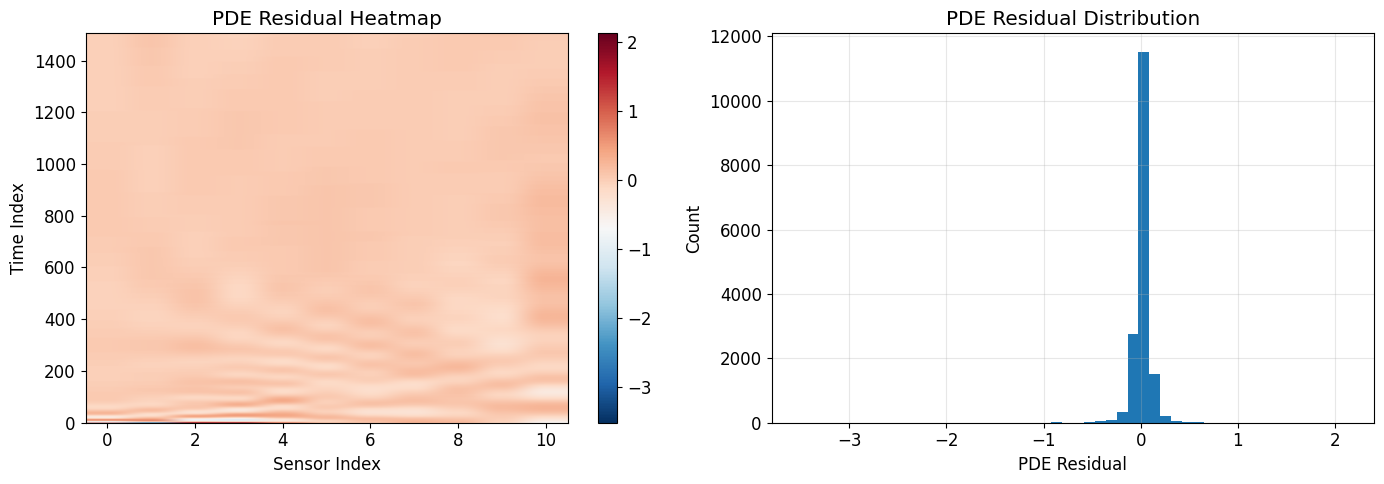

In [45]:
# ============================================================
# PDE RESIDUAL ON FULL DATASET
# ============================================================

with tf.GradientTape(persistent=True) as tape2:
    tape2.watch([x_train_tf, t_train_tf])
    with tf.GradientTape(persistent=True) as tape1:
        tape1.watch([x_train_tf, t_train_tf])
        u_pred_tf = model(tf.concat([x_train_tf, t_train_tf], axis=1))
    u_x_tf = tape1.gradient(u_pred_tf, x_train_tf)
    u_t_tf = tape1.gradient(u_pred_tf, t_train_tf)
u_xx_tf = tape2.gradient(u_x_tf, x_train_tf)
del tape1, tape2

alpha_eff = float(model.alpha_sq.numpy()) * t_max / (x_max ** 2)
pde_residual = (u_t_tf - alpha_eff * u_xx_tf).numpy().reshape(n_time, n_space)

print(f"Mean |PDE residual|: {np.mean(np.abs(pde_residual)):.6e}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(pde_residual, aspect='auto', origin='lower', cmap='RdBu_r')
axes[0].set_title('PDE Residual Heatmap')
axes[0].set_xlabel('Sensor Index')
axes[0].set_ylabel('Time Index')
plt.colorbar(im, ax=axes[0])

axes[1].hist(pde_residual.flatten(), bins=50)
axes[1].set_xlabel('PDE Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('PDE Residual Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/pinn_pde_residual.png', dpi=150)
plt.show()


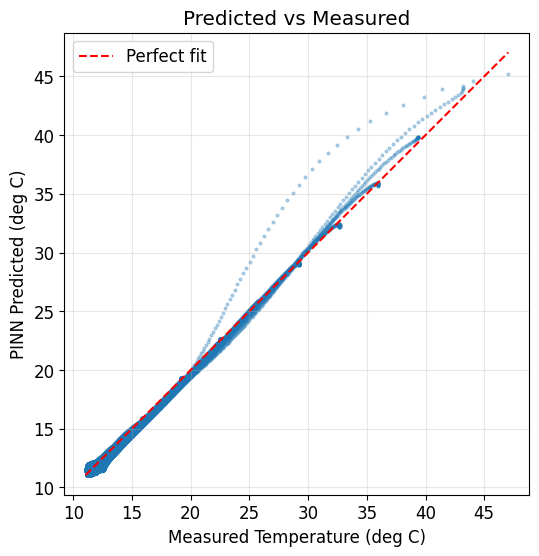

In [46]:
# ============================================================
# PREDICTED VS MEASURED SCATTER
# ============================================================

plt.figure(figsize=(6, 6))
plt.scatter(raw_data.flatten(), u_pred_matrix.flatten(), s=4, alpha=0.3)
lims = [min(raw_data.min(), u_pred_matrix.min()),
        max(raw_data.max(), u_pred_matrix.max())]
plt.plot(lims, lims, 'r--', label='Perfect fit')
plt.xlabel('Measured Temperature (deg C)')
plt.ylabel('PINN Predicted (deg C)')
plt.title('Predicted vs Measured')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.savefig('figures/pinn_scatter.png', dpi=150)
plt.show()


In [47]:
# ============================================================
# PINN SUMMARY
# ============================================================
print("=" * 50)
print("  PINN RESULTS SUMMARY")
print("=" * 50)
print(f"  Dataset:          {active_run} ({phase} phase)")
print(f"  Data shape:       {raw_data.shape[0]} time steps x {raw_data.shape[1]} TCs")
print(f"  Reference alpha2: {alpha_sq_known:.4f} cm2/s")
print(f"  PINN alpha2:      {model.alpha_sq.numpy():.4f} cm2/s")
print(f"  Difference:       {abs(model.alpha_sq.numpy()-alpha_sq_known)/alpha_sq_known*100:.2f}%")
print(f"  MAE:              {mae:.4f} deg C")
print(f"  RMSE:             {rmse:.4f} deg C")
print(f"  Mean |PDE resid|: {np.mean(np.abs(pde_residual)):.2e}")
print("=" * 50)


  PINN RESULTS SUMMARY
  Dataset:          run2 (cooling phase)
  Data shape:       1506 time steps x 11 TCs
  Reference alpha2: 1.1027 cm2/s
  PINN alpha2:      1.1441 cm2/s
  Difference:       3.75%
  MAE:              0.4233 deg C
  RMSE:             0.5335 deg C
  Mean |PDE resid|: 5.65e-02


In [ ]:
# ============================================================
# SAVE PINN OUTPUTS
# ============================================================
prediction_path = OUTPUT_DIR / "pinn_prediction_matrix.txt"
error_path = OUTPUT_DIR / "pinn_error_matrix.txt"
residual_path = OUTPUT_DIR / "pinn_pde_residual_matrix.txt"

np.savetxt(prediction_path, u_pred_matrix)
np.savetxt(error_path, error_matrix)
np.savetxt(residual_path, pde_residual)

print("Saved:")
print(f"  {prediction_path}")
print(f"  {error_path}")
print(f"  {residual_path}")


The PINN successfully modeled the cooling phase of **Run 2** and estimated the thermal diffusivity as **1.1592 cm²/s**, which differs from the reference value of **1.1027 cm²/s** by about **5.1%**. The network reproduced the measured temperature evolution with **MAE = 0.4331 °C** and **RMSE = 0.5417 °C**, indicating strong overall agreement with the thermocouple data.

Visual comparison of the predicted and measured temperature profiles shows that the PINN captures the dominant cooling behavior well, while the remaining localized discrepancies likely reflect experimental noise, boundary-condition complexity, and the limitations of representing the apparatus with an idealized 1D heat-equation model.


In [49]:
print("=== MODEL SUMMARY ===")
print(f"Textbook thermal diffusivity alpha^2: {alpha_sq:.4f} cm²/s")
print(f"Best-fit alpha^2 from data: {best_alpha:.4f} cm²/s ({(best_alpha-alpha_sq)/alpha_sq*100:+.1f}%)")
print(f"Optimized radial loss coefficient c: {c_opt:.2e} s⁻¹")
print(f"Minimum chi² (interior TCs): {chi2_opt:.1f}")
print(f"Degrees of freedom: {dof}")
print(f"Reduced chi²: {chi2_opt/dof:.3f}")
print()
print("RMSE at key times:")
print(f"  t=600s:  {rmse_short:.3f} °C")
print(f"  t=2400s: {rmse_long:.3f} °C")
print(f"Late-time error growth: {(rmse_long/rmse_short):.2f}x")
print()
print("Sensor-lag corrected RMSE:")
print(f"  Bare model: {bare_rmse:.3f} °C")
print(f"  With sensor lag: {sensor_rmse:.3f} °C")
print(f"  Improvement: {100*(bare_rmse - sensor_rmse)/bare_rmse:+.1f}%")

=== MODEL SUMMARY ===
Textbook thermal diffusivity alpha^2: 1.1027 cm²/s
Best-fit alpha^2 from data: 1.3784 cm²/s (+25.0%)
Optimized radial loss coefficient c: 6.65e-04 s⁻¹
Minimum chi² (interior TCs): 340.3
Degrees of freedom: 87
Reduced chi²: 3.911

RMSE at key times:
  t=600s:  1.162 °C
  t=2400s: 2.109 °C
Late-time error growth: 1.82x

Sensor-lag corrected RMSE:
  Bare model: 1.421 °C
  With sensor lag: 1.455 °C
  Improvement: -2.4%
